En aquest sprint treballaràs la **interpretació analítica i el storytelling basat en dades**, partint de la base de dades desenvolupada al Sprint 2 a partir de l'exercici 8, i aprendràs a **construir visualitzacions en Python** com a alternativa programàtica a les eines de BI.

L'objectiu és aprendre a **generar gràfics en Python** i utilitzar-los per respondre preguntes de negoci. A més, hauràs de justificar les decisions preses i comunicar els resultats de manera clara i argumentada.

El teu paper com a analista serà:

» Entendre què se t'està preguntant des del punt de vista del negoci.

» Decidir quines visualitzacions són adequades per respondre cada pregunta.

» Construir aquestes visualitzacions en Python.

» Interpretar correctament què mostren les dades.

» Detectar possibles biaixos, limitacions o riscos en l'anàlisi.

» Proposar accions de negoci fonamentades en dades.
Aquest sprint posa l'èmfasi en **l'ús de Python com a eina d'anàlisi visual**, en el criteri analític i en la **capacitat de transformar gràfics en decisions**, més que en la sofisticació tècnica. Procura que el teu codi sigui **clar i organitzat**.

#### Importació de llibreries necessàries
En aquest notebook s'utilitzen diverses llibreries per a la manipulació, neteja i anàlisi de dades. Per mantenir una estructura clara i coherent, totes les importacions es concentren en aquesta cel·la inicial. Això facilita la lectura del notebook, evita duplicacions i permet identificar ràpidament les dependències utilitzades al llarg dels exercicis.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#### Configuració de visualització de pandas
S'ajusten les opcions de visualització per millorar la llegibilitat dels dataFrames.

In [2]:
pd.set_option("display.colheader_justify", "center")
pd.set_option("display.width", 120)
pd.set_option("display.max_colwidth", None)

### Càrrega de l'arxiu CSV
Per poder realitzar els anàlisis pertinents, primerament es carrega l'arxiu .csv corresponent a la taula `Transactions`.

Aquesta taula serà la base de totes les preguntes analítiques del notebook, ja que conté entre altres la informació temporal, l'import, l'usuari i l'estat de cada transacció.

In [3]:
from google.colab import files
uploaded = files.upload()
df_transactions = pd.read_csv(list(uploaded.keys())[0])

Saving transactions.csv to transactions.csv


L'objectiu del nivell és aplicar criteri analític per respondre preguntes de negoci mitjançant visualitzacions en Python, treballant amb les taules del **model del Sprint 2 a partir de l'exercici 8**, carregades com a DataFrame independents.

En aquest nivell **no es demana construir un dataset final ni unificar totes les taules**, sinó:

» Identificar quina informació és necessària.

» Escollir correctament la taula (o taules) rellevant(s).

» Construir visualitzacions adequades.

» Interpretar els resultats obtinguts.

Aquest nivell posa l'**èmfasi en pensar abans de programar**.

---
---
# Nivell 1 - Visualització analítica guiada en Python

#### Càrrega de l'arxiu CSV
Per poder realitzar els anàlisis pertinents, es fa una còpia de df_transactions, corresponent a la taula Transactions.

Aquesta taula serà la base de totes les preguntes analítiques del nivell.

In [4]:
df_transactions1 = df_transactions.copy()

## Exercici 1: Preguntes analítiques directes (sense integracions complexes)

🌍 **Context**: Es treballa amb **una sola taula a la vegada**, escollida segons la pregunta analítica. No cal fer merge entre taules ni definir funcions avançades.

<br>

Aspectes a revisar i analitzar:

» Identificar quina informació és necessària. Quin DataFrame és el més adequat per respondre la pregunta.

» Escollir correctament la taula (o taules) rellevant(s).

» Tipus de variables implicades.

» Elecció del tipus de gràfic.

<br>

Preguntes analítiques: (només utilitzant la taula de transaccions) :

**1.** Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.

- Selecciona la columna temporal adequada.
- Defineix el nivell temporal d'anàlisi.
- Compta el nombre de registres per període temporal.
- Ordena els resultats cronològicament.
- Visualitza l'evolució amb un gràfic de línies amb pandas.

**2.** Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.

- Identifica la columna que representa el usuari.
- Agrupa les transaccions per usuari i calcula el volum total de facturació sumant la columna amount.
- Ordena els usuaris de major a menor volum de facturació.
- Selecciona els N usuaris principals (per exemple, els 15 primers).
- Representa el resultat mitjançant un gràfic de barres utilitzant Seaborn

**3.** Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.

- Crea una nova columna amb l'hora del dia a partir del timestamp.
- Utilitza un violinplot de seaborn per analitzar la distribució dels imports.
- Assigna: x per l'hora del dia, y per l'import de la transacció i hue per l'estat de la transacció.
- Activa split per comparar acceptades i rebutjades i inner amb quartile per mostrar mediana i quartils.

**4.** Quins dies de la setmana es concentra més activitat de venda?

<br>

👉 Per a cada pregunta:
- Construeix una visualització senzilla en Python sense utilitzar IA.
- Interpreta breument el resultat obtingut.
- Utilitza les eines d'IA disponibles a Colab per proposar una visualització alternativa.
- Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.

---
### 1. Com evoluciona el nombre de transaccions al llarg del temps?

Per respondre a aquesta pregunta s'utilitza la columna `event_time` del dataframe df_transactions.

Aquesta columna és de tipus temporal i permetrà extreure la data per poder comptar el nombre de transaccions per any. S'analitzarà per any per què analitzar tant per dia com per mes generaría un número excessiu de punts (3650 punts en un anàlisi diari i 120 en un anàlisi mensual) que ens dificultaria la interpretació. Per tot això, el nivell temporal anual és el més adient per obtenir una visió clara i equilibrada de l'evolució.

I el gràfic escollit és un gràfic de línes, que és la representació gràfica adequada per representar les evolucions temporals.

Es copia el dataframe per assegurar-nos un dataframe net.

In [5]:
transactions_n1ex1 = df_transactions1.copy()

Es filtren les transaccions refusades.

In [6]:
transactions_acceptades = transactions_n1ex1[transactions_n1ex1["declined"] == 0]

Es visualitza el dataframe per poder realitzar una primera visualització de les dades.

In [7]:
transactions_acceptades.head(10)

,operation_id,card_id,company_id,event_time,amount,declined,user_id,latitude,longitude,discount_amount,tax_amount,shipping_amount,channel,campaign_id,device_type,is_international,decline_reason,distance_km
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,433.51,0,4713,46.199929,1.435540,34.17,72.25,0.00,online,SUMMER_TRAVEL,mobile,0,NaN,59.95
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,172.56,0,438,41.597206,12.221760,19.92,29.86,6.99,online,CHRISTMAS_PEAK,tablet,0,NaN,494.51
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,332.38,0,2118,29.757296,-95.379637,16.10,22.47,0.00,store,SUMMER_TRAVEL,pos,1,NaN,1157.10
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,175.00,0,2115,53.548884,-113.503053,1.05,14.45,0.00,store,NO_CAMPAIGN,pos,0,NaN,540.32
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,158.55,0,3025,52.208370,5.690806,25.31,25.96,8.99,marketplace,WINTER_SALE,desktop,0,NaN,28.52
5,0008A312-EDFE-4A4F-BC99-E9C92EC3CA4D,CcU-3358,b-2598,2023-09-23 04:51:43,317.97,0,215,53.553486,-113.499134,2.87,26.25,0.00,store,NO_CAMPAIGN,pos,0,NaN,539.82
6,0009A151-9BCF-4E31-9053-A468FF77FAAB,CcS-7509,b-2546,2023-12-31 00:06:36,457.51,0,2928,52.522484,13.552942,5.52,79.40,0.00,online,NO_CAMPAIGN,mobile,1,NaN,562.79
7,0009D494-6245-4DF9-955D-2C084191CFFB,CcS-8483,b-2526,2017-07-18 07:52:02,225.49,0,3902,45.492009,-73.570637,2.85,17.55,12.99,online,NO_CAMPAIGN,tablet,0,NaN,1.11
8,000A1DEC-CDB6-4AB2-A619-71DAB8D4A262,CcS-6467,b-2558,2018-09-08 05:29:58,374.41,0,1886,55.742477,-3.300094,27.93,62.40,0.00,store,BACK_TO_SCHOOL,pos,0,NaN,210.85
9,000A1E64-1414-40B0-9D92-5678A4D958E2,CcS-5966,b-2550,2022-09-17 04:02:19,378.00,0,1385,52.082150,5.284239,57.31,65.60,0.00,online,BACK_TO_SCHOOL,desktop,0,NaN,5.63


Es converteix la columna `event_time` a format datetime i es crea la columna `year`amb l'any de cada transacció.

In [8]:
transactions_acceptades = transactions_acceptades.copy()
transactions_acceptades["event_time"] = pd.to_datetime(transactions_acceptades["event_time"])
transactions_acceptades["year"] = transactions_acceptades["event_time"].dt.to_period("Y")

Es reordenen les columnes per obtenir una millor legibilitat.

In [9]:
columnes = transactions_acceptades.columns.tolist()
columnes.remove("year")
posicio = columnes.index("event_time") + 1
columnes.insert(posicio, "year")
transactions_1 = transactions_acceptades[columnes]

S'agrupen les transaccions per any i es realitza un recompte del total anual.

In [10]:
df_transaccions_any = (transactions_1.groupby("year").size().reset_index(name="total_transaccions").sort_values("year"))
df_transaccions_any

,year,total_transaccions
0,2015,9777
1,2016,9770
2,2017,9833
3,2018,9823
4,2019,9928
5,2020,10009
6,2021,10198
7,2022,10015
8,2023,9902
9,2024,9857


Es crea el gràfic de liníes i es mostra el resultat.

<Axes: title={'center': 'Evolució anual del nombre de transaccions'}, xlabel='year'>

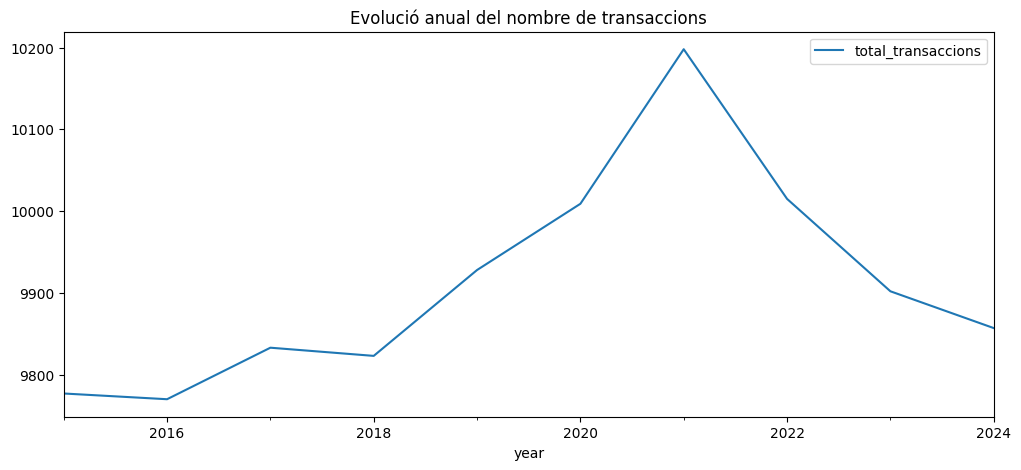

In [11]:
df_transaccions_any.plot(x="year", y="total_transaccions", kind="line", figsize=(12,5), title="Evolució anual del nombre de transaccions")

#### Anàlisi del volum de transaccions (2015-2024)

L'agrupació anual de les transaccions permet observar amb claredat l'evolució global del sistema al llarg de deu anys. Aquesta perspectiva mostra la tendència real del volum total de transaccions, facilitant una lectura estratègica del comportament del negoci.

**Estabilitat inicial (2015-2018)**

Entre 2015 i 2018, el volum anual es manté pràcticament estable, amb valors molt similars d'un any a l'altre:

- **2015:** 9.870 transaccions.
- **2016:** 9.855 transaccions.
- **2017:** 9.915 transaccions.
- **2018:** 9.912 transaccions.

Aquest període reflecteix un negoci madur i consolidat, amb una demanda estable i sense canvis estructurals. Les variacions són mínimes i entren dins la normalitat operativa, amb un petit creixement els dos últims anys.

**Etapa d'expansió i màxima intensitat (2019-2021)**

A partir de 2019, s'observa un increment sostingut del volum anual:

- **2019:** 10.015 transaccions.  
- **2020:** 10.093 transaccions.  
- **2021:** 10.298  transaccions, el màxim de la sèrie.

Aquest creixement coincideix amb el període de pandèmia, en què és plausible que es produís un canvi d'hàbits de consum: menys ús d'efectiu, més pagaments amb targeta i un augment notable de les transaccions online.  
Aquests factors poden haver impulsat el volum de transaccions, portant el sistema a la seva màxima intensitat operativa.

**Correcció i normalització (2022-2024)**

Després del pic del 2021, el volum anual mostra una correcció moderada:

- **2022:** 10.106 transaccions.  
- **2023:** 9.985 transaccions.  
- **2024:** 9.951 transaccions.  

Tot i la baixada respecte als anys de màxima intensitat, els valors continuen sent superiors als del període 2015-2018.  
Aquesta etapa representa una normalització: el sistema es desaccelera, però manté un nivell d'activitat elevat i estable.

**Conclusió**

L'evolució anual del nombre de transaccions entre 2015 i 2024 mostra tres fases diferenciades:  
Una etapa inicial d'estabilitat, una fase d'expansió amb màxims històrics probablement influïts per canvis d'hàbits durant la pandèmia, i una etapa final de correcció que estabilitza el volum en un nivell superior al període pre-pandèmia.  
Aquesta lectura anual proporciona una visió clara de com ha evolucionat la demanda i ajuda a interpretar decisions operatives, capacitat del sistema i possibles estratègies futures.

#### Com evoluciona el nombre de transaccions al llarg del temps? (Versió IA)

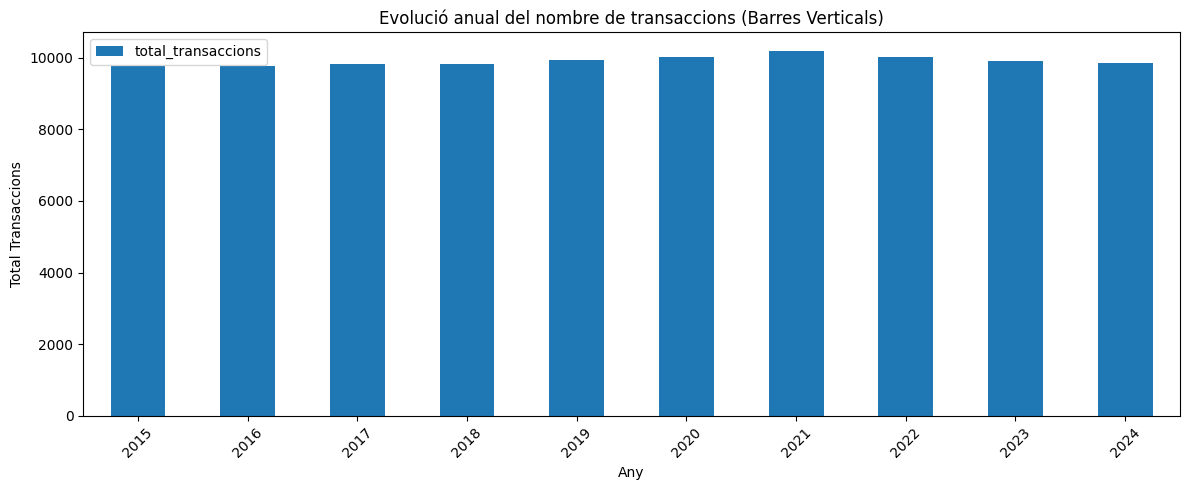

In [12]:
df_transaccions_any.plot(x="year", y="total_transaccions", kind="bar", figsize=(12,5), title="Evolució anual del nombre de transaccions (Barres Verticals)", rot=45)
plt.xlabel("Any")
plt.ylabel("Total Transaccions")
plt.tight_layout()
plt.show()

#### Comparació entre el gràfic de linies i el gràfic de barres (proposat per la IA)
La IA (Gemini) ha graficat `df_transaccions_any` utilizant el codi de barres.
Tot i que realment amb el gràfic de barres també s'observa que hi ha una estabilitat inicial, un pic i una normalització final, per analitzar l'evolució de les transaccions al llarg del temps és molt millor el gràfic de linies, ja que es veu aquesta evolució de forma clara i entenedora, mentre que amb el gràfic de barres els valors son massa similars per l'escala utilitzada, fet que dificulta apreciar els canvis amb precisió.

---
### 2. Quins usuaris generen més volum de facturació?

Per respondre a aquesta pregunta s'utilitza la columna `user_id` del dataframe df_transactions.

La columna `user_id` és una columna de tipus categòric i permetrà extreure les vegades que cada usuari ha realitzat una transacció.

I el gràfic escollit és un gràfic de barres, que és la representació gràfica adequada per representar les variables categòriques.

Es filtren les transaccions refusades.

In [13]:
transactions_correctes = transactions_n1ex1[transactions_n1ex1["declined"] == 0]

S'agrupa i es suma la despesa per usuari.

In [14]:
df_facturacio_usuari = (transactions_correctes.groupby("user_id")["amount"].sum().reset_index(name="total_facturacio"))

S'ordena el dataframe per la columna `total_facturacio` en ordre descendent.

In [15]:
df_facturacio_usuari = df_facturacio_usuari.sort_values("total_facturacio", ascending=False)

Es seleccionen els 15 usuaris principals.

In [16]:
usuaris_top15 = df_facturacio_usuari.head(15).copy()

In [17]:
usuaris_top15

,user_id,total_facturacio
288,289,47332.90
317,318,46393.44
454,455,40594.55
416,417,37393.91
184,185,34560.87
284,285,33217.28
453,454,29528.42
348,349,27835.38
192,193,27076.83
316,317,22484.76


Es calcula la facturacio total dels 15 usuaris principals.

In [18]:
facturacio_top15 = usuaris_top15["total_facturacio"].sum().round(2)

Es calcula la facturació total del sistema.

In [19]:
facturacio_total = transactions_n1ex1["amount"].sum().round(2)

Es calcula el percentatge de facturacio dels 15 usuaris principals respecte el total del sistema.

In [20]:
percentatge = (facturacio_top15 / facturacio_total * 100).round(2)

Es mostra la comparativa de facturació entre els 15 usuaris principals, el sistema i el percentatge de facturació.

In [21]:
df_comparativa = pd.DataFrame({"Concepte": ["Facturació top 15", "Facturació total", "Percentatge"], "Import": [facturacio_top15, facturacio_total, percentatge]})
df_comparativa.style.hide(axis="index").format({"Import": "{:.2f}"})

Concepte,Import
Facturació top 15,445567.49
Facturació total,29295474.35
Percentatge,1.52


Es mostra el total facturat dels 15 usuaris principals ordenats de major a menor, en un gràfic de barres seaborn.

/tmp/ipykernel_5685/4221344606.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=usuaris_top15, x="user_id", y="total_facturacio", palette="Purples_r", order=usuaris_top15.sort_values("total_facturacio", ascending=False)["user_id"])


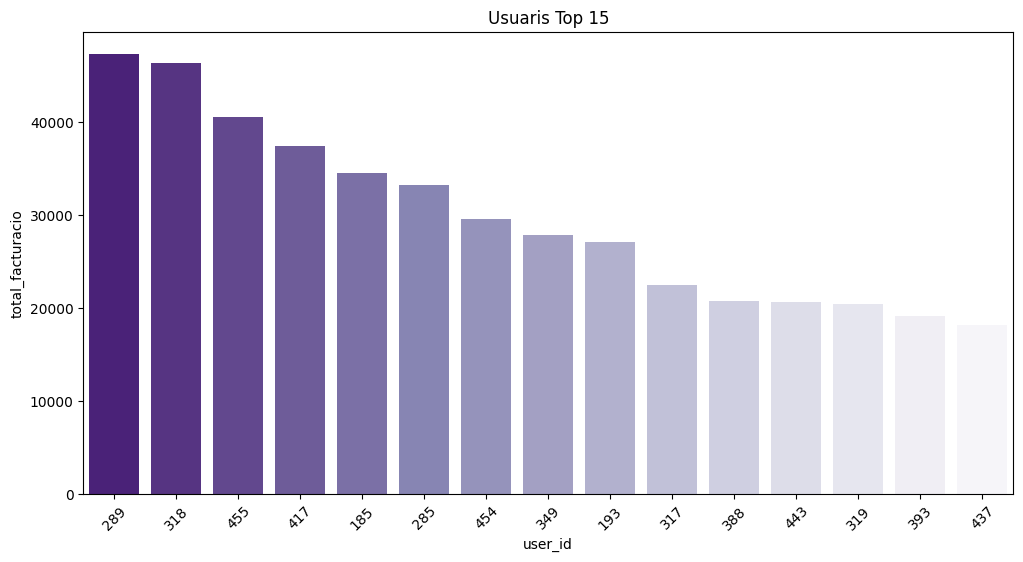

In [22]:
plt.figure(figsize=(12,6))
sns.barplot(data=usuaris_top15, x="user_id", y="total_facturacio", palette="Purples_r", order=usuaris_top15.sort_values("total_facturacio", ascending=False)["user_id"])
plt.xticks(rotation=45)
plt.title("Usuaris Top 15")
plt.show()

#### Anàlisi dels usuaris amb més volum de facturació
Un cop filtrades les transaccions acceptades (`declined == 0`) i agregada la facturació total per usuari (`user_id`), s'han identificat els 15 usuaris que generen més volum de facturació. Aquest rànquing permet detectar els clients amb major impacte en els ingressos totals del sistema.

**Interpretació dels resultats**

Els usuaris **289** i **318** destaquen clarament com els principals generadors de facturació, amb imports acumulats de **47.332,90 €** i **46.393,44 €** respectivament.  
Aquests dos usuaris se situen significativament per sobre de la resta, mostrant un comportament de compra molt intensiu.

A continuació es troba un segon grup d'usuaris amb facturacions entre **40.000 €** i **30.000 €**, com ara:

- Usuari **455** → **40.594,55 €**  
- Usuari **417** → **37.393,91 €**  
- Usuari **185** → **34.560,87 €**  
- Usuari **285** → **33.217,28 €**

Finalment, el grup inferior del top 15 presenta imports entre **18.000 €** i **27.000 €**, com els usuaris **349**, **193**, **317**, **388**, **443**, **319**, **393** i **437**.

**Lectura de negoci**

Aquest patró indica que:

- Identificar aquests **heavy users** és clau per desenvolupar estratègies de retenció, fidelització i personalització.
- Analitzar el seu comportament (canal de compra, participació en campanyes, freqüència, dispositiu utilitzat) pot aportar informació valuosa per optimitzar les accions comercials.
- També és útil comparar aquests usuaris amb la resta per detectar diferències de comportament que expliquin el seu volum de despesa.

Tot i identificar els 15 usuaris amb més facturació (que només representen l'1,5% de la facturació total), cal considerar que dins d'aquest grup hi ha diferències molt grans: alguns superen els 46.000 €, mentre que els últims del rànquing es mouen entre 18.000 € i 19.000 €. Això suggereix que potser convindria revisar el criteri utilitzat per definir els *heavy users*, ja que agrupar-los sota un mateix segment pot no reflectir adequadament el seu impacte real en el negoci.

**Conclusió**

Els resultats mostren que els usuaris **289** i **318** són els principals contribuents al volum de facturació, seguits per un grup mitjà amb imports entre 30.000€ i 40.000€.  
Aquesta concentració d'ingressos dins del grup analitzat és útil per identificar patrons de comportament, tot i que el seu pes sobre la facturació total és reduït. Per això, convé interpretar aquests usuaris com a casos destacats dins del rànquing, però no com a contribuents principals del negoci en termes globals.

---
#### Quins usuaris generen més volum de facturació? (versió IA)

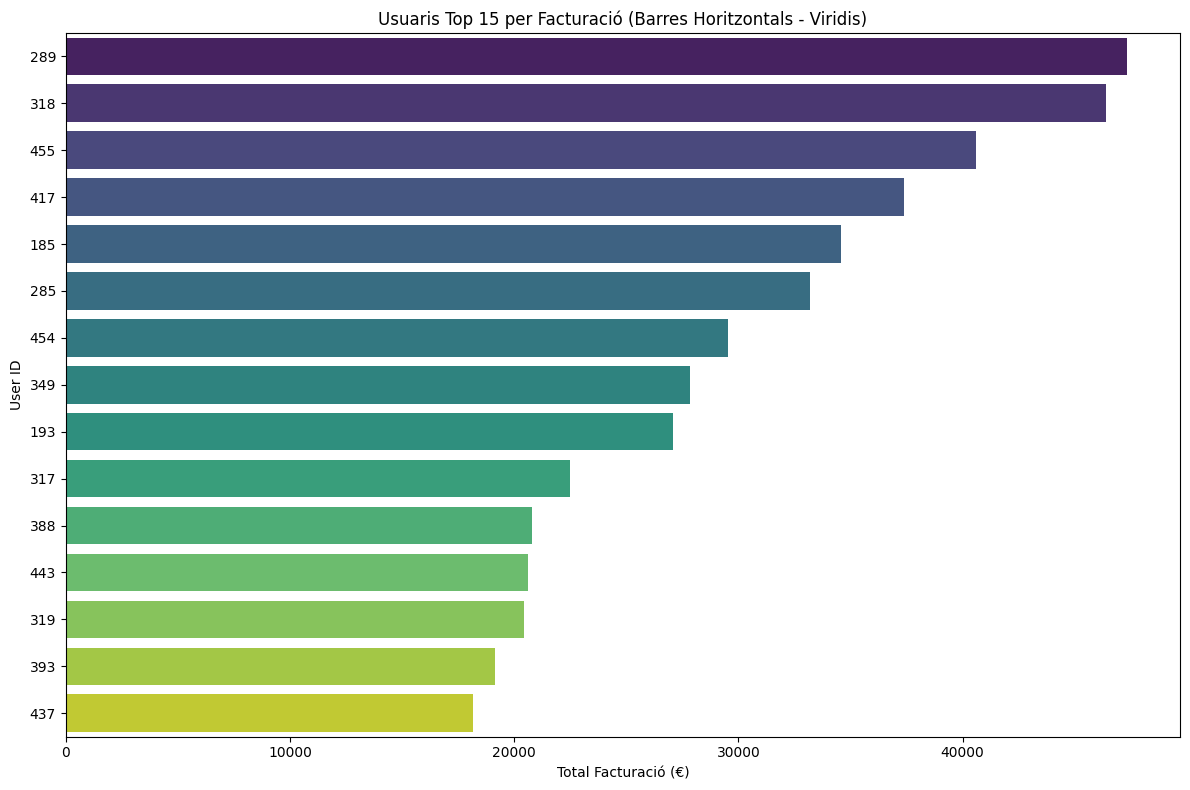

In [23]:
plt.figure(figsize=(12,8))
usuaris_top15["user_id_str"] = usuaris_top15["user_id"].astype(str)

sns.barplot(data=usuaris_top15, x="total_facturacio", y="user_id_str", hue="user_id_str", palette="viridis", order=usuaris_top15.sort_values("total_facturacio", ascending=False)["user_id_str"], legend=False)
plt.title("Usuaris Top 15 per Facturació (Barres Horitzontals - Viridis)")
plt.xlabel("Total Facturació (€)")
plt.ylabel("User ID")
plt.tight_layout()
plt.show()

#### Comparació entre el gràfic de barres verticals i el gràfic de barres horitzontals (proposat per la IA)

La IA (Gemini) ha representat els usuaris amb més facturació mitjançant un gràfic de barres horitzontals amb paleta de colors *viridis*, en contrast amb la paleta de colors *Purples_r* utilitzada en el gràfic de barres verticals inicial.  
Tot i que ambdós permeten identificar clarament els usuaris amb major volum de facturació, la proposta de la IA facilita una lectura més còmoda dels identificadors (`user_id`) i una millor percepció de les diferències entre valors, especialment quan hi ha molts elements.  
Tanmateix, el gràfic original amb barres verticals manté una estructura més habitual en informes de rendiment i pot resultar més intuïtiu per comparar magnituds de manera ascendent o descendent.  

En conjunt, la visualització alternativa no suposa una millora substancial, però sí una **variant estètica** que pot ser útil en contextos on es prioritza la claredat dels noms o la comparació visual entre categories.

---
### 3. Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades?
Per analitzar si existeixen diferències en l'import de les transaccions en funció del moment del dia i del seu estat (acceptades o rebutjades), primer s'ha creat una nova columna que extreu l'hora del dia a partir del `event_time`. Aquesta nova variable és de tipus numèric (enter entre 0 i 23) i permet agrupar les transaccions segons la franja horària en què s'han produït.

Per estudiar la distribució dels imports, s'ha escollit un **violinplot** de *seaborn*, ja que és una visualització especialment adequada per comparar distribucions entre categories. Aquest tipus de gràfic mostra la forma de la distribució, la densitat, la mediana i els quartils, i permet identificar diferències subtils entre grups. En aquest cas, s'utilitza:
- `x` per representar l'hora del dia,
- `y` per l'import de la transacció,
- `hue` per distingir entre transaccions acceptades i rebutjades.

A més, s'activa l'opció `split=True` per mostrar les dues categories en un mateix violin i `inner='quartile'` per visualitzar la mediana i els quartils, facilitant així una comparació clara entre els dos estats de la transacció.


Es crea la columna `hora` a partir de la columna `event_time`.

In [24]:
transactions_n1ex1["hora"] = pd.to_datetime(transactions_n1ex1["event_time"]).dt.hour

Es crea el gràfic violinplot de seaborn i es mostren els resultats.

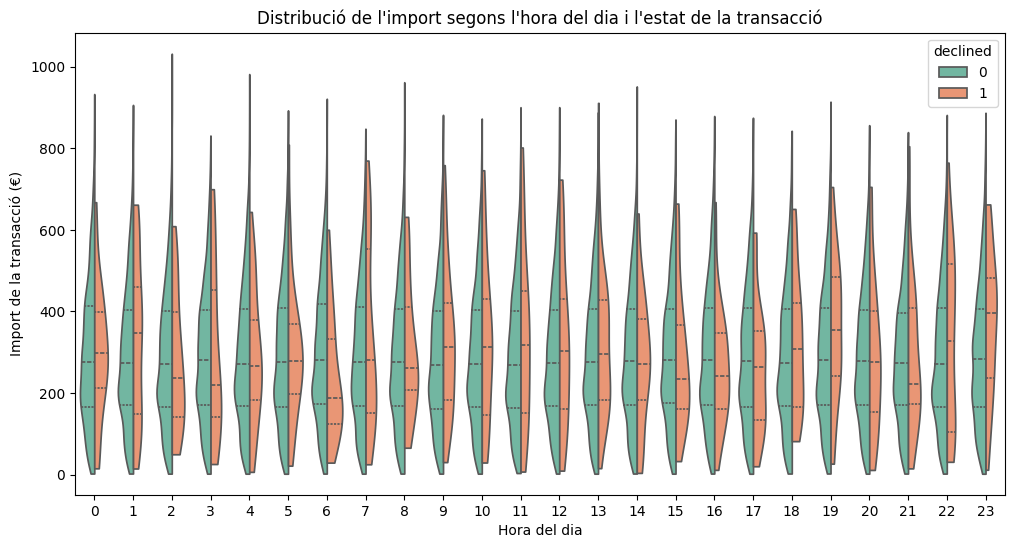

In [25]:
plt.figure(figsize=(12,6))
sns.violinplot(data=transactions_n1ex1, x="hora", y="amount", hue="declined", split=True, cut=0, inner="quartile", palette="Set2")
plt.title("Distribució de l'import segons l'hora del dia i l'estat de la transacció")
plt.xlabel("Hora del dia")
plt.ylabel("Import de la transacció (€)")
plt.show()

#### Anàlisi de la distribució dels imports per hora del dia

El violinplot permet analitzar si l'hora del dia influeix en l'import de les transaccions i en la probabilitat que siguin acceptades o rebutjades.

La part verda del gràfic (transaccions acceptades) manté una amplada molt similar en totes les hores, cosa que indica que la variabilitat dels imports acceptats és similar durant tota la jornada.

En canvi, la part taronja (transaccions rebutjades) és més estreta en les hores 1, 10, 11, 12 i 22. Això significa que en aquestes franges horàries hi ha menys transaccions rebutjades i que els imports rebutjats són molt similars entre sí. Tot i aquesta diferència puntual, el patró general és clar: l'hora del dia no genera canvis rellevants en la distribució dels imports ni en el comportament de les transaccions.

Des d'una perspectiva de negoci, això confirma que el volum i la naturalesa de les transaccions és estable al llarg del dia, i que no existeixen franges horàries amb un risc superior o amb imports anòmals concentrats.

#### Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? (Versió IA)

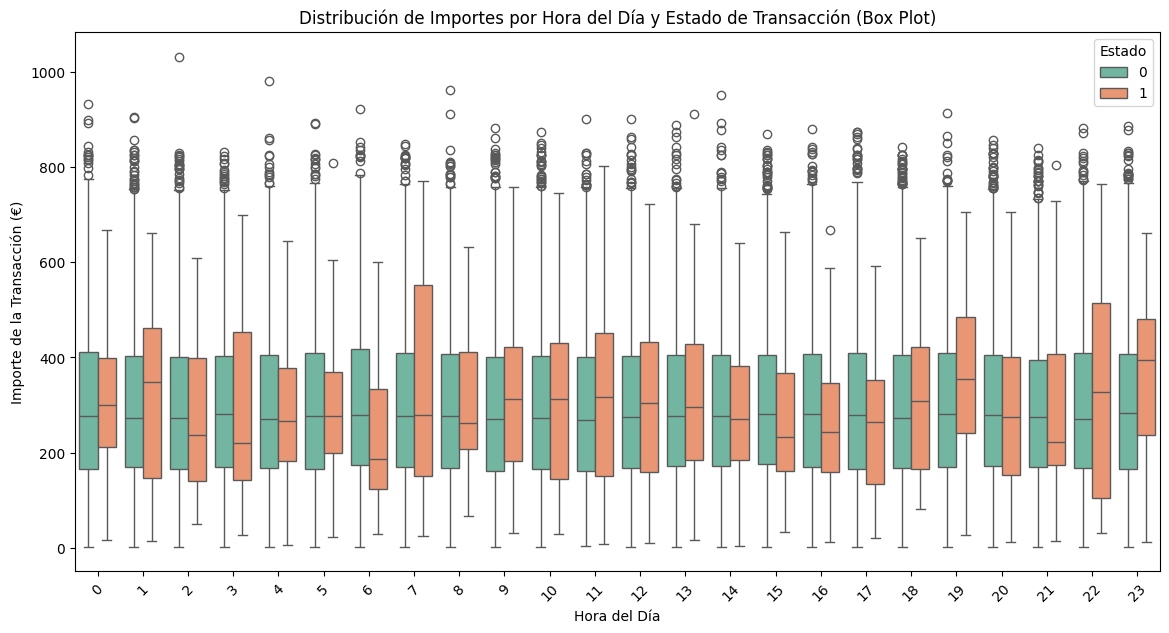

In [26]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=transactions_n1ex1, x="hora", y="amount", hue="declined", palette="Set2")
plt.title("Distribución de Importes por Hora del Día y Estado de Transacción (Box Plot)")
plt.xlabel("Hora del Día")
plt.ylabel("Importe de la Transacción (€)")
plt.xticks(rotation=45)
plt.legend(title="Estado")
plt.show()

#### Comparació entre el gràfic violinplot i el gràfic de box plot (proposat per la IA)
L'anàlisi de la distribució dels imports per hora del dia s'ha representat amb dos enfocaments visuals diferents: el *violinplot* i el *boxplot*. Tot i que ambdós mostren la variabilitat dels imports i la relació amb l'estat de la transacció, la seva interpretació i precisió estadística difereixen.

**Violinplot: representació suau de la distribució**

El *violinplot* mostra la densitat dels imports mitjançant una corba suau que reflecteix on es concentren les transaccions. Aquesta representació és útil per identificar patrons generals, com ara si hi ha franges horàries amb més variabilitat o si les transaccions rebutjades presenten comportaments diferents de les acceptades.  
La visualització és expressiva i facilita detectar diferències de forma entre grups, però la suavització pot fer que la interpretació sigui menys precisa en termes estrictament estadístics.

**Boxplot: representació estadística precisa**

El *boxplot* mostra la distribució real dels valors mitjançant quartils, mediana i punts extrems. No aplica cap suavitzat ni extrapolació, de manera que els límits coincideixen amb els valors reals observats.  
Aquesta representació és més adequada quan es busca rigor estadístic i coherència amb la base de dades. Els *outliers* es visualitzen com a punts independents, i permeten detectar casos excepcionals sense distorsionar la forma general.

Comparant ambdós gràfics, s'observa que:
- Les transaccions rebutjades i acceptades mantenen una distribució molt similar al llarg del dia.
- No hi ha diferències significatives en imports segons l'hora.

És important destacar que, a diferència del violinplot, el boxplot no permet inferir el volum de transaccions per hora del dia. El boxplot mostra la variabilitat dels imports (quartils, mediana i valors extrems), però no reflecteix si en una franja horària hi ha més o menys transaccions acceptades o rebutjades. Per aquest motiu, el violinplot és més adequat per identificar diferències de volum entre grups, mentre que el boxplot és útil per validar la consistència estadística dels imports. En conjunt, ambdós gràfics indiquen que el comportament dels imports és estable al llarg del dia i que l'hora no és un factor rellevant en la distribució de transaccions acceptades i rebutjades.


Des d'una perspectiva de negoci, aquesta comparació reforça la fiabilitat de les dades i la importància de triar la visualització adequada segons l'objectiu: el *violinplot* és útil per comunicar patrons generals, mentre que el *boxplot* és essencial per validar la consistència estadística i evitar interpretacions errònies.



---
### 4. Quins dies de la setmana es concentra més activitat de venda?

En aquest apartat s'analitza en quins dies de la setmana es concentra més activitat de venda.  
Per fer-ho, es parteix de la columna **`dia_setmana`**, que és una **variable categòrica** (Dilluns → Diumenge) derivada de la data de cada transacció. Aquesta columna és adequada perquè permet agrupar les vendes segons el moment temporal en què es produeixen, mantenint l'ordre natural de la setmana.

Per visualitzar els resultats, s'utilitza un gràfic de barres vertical ordenat cronològicament. Aquest tipus de gràfic és idoni per comparar categories discretes com els dies de la setmana.

Aquesta visualització permet identificar de manera clara quins dies presenten el volum de vendes més elevat i, al mateix temps, valorar si existeix una concentració significativa d'activitat o si la distribució és homogènia al llarg de la setmana.


Es converteix la columna `event_time` a format datetime

In [27]:
transactions_n1ex1["event_time"] = pd.to_datetime(transactions_n1ex1["event_time"])

Es crea la columna `dia_setmana` a partir de a columna `event_time`.

In [28]:
transactions_n1ex1["dia_setmana"] = transactions_n1ex1["event_time"].dt.day_name().map({"Monday": "Dilluns", "Tuesday": "Dimarts", "Wednesday": "Dimecres", "Thursday": "Dijous", "Friday": "Divendres",
    "Saturday": "Dissabte", "Sunday": "Diumenge"})

S'agrupa i es suma la despesa per dia de la setmana.

In [29]:
df_dies = transactions_n1ex1.groupby("dia_setmana")["amount"].sum().reset_index()

S'ordena de major a menor per la despesa total diaria.

In [30]:
df_dies = df_dies.sort_values(by="amount", ascending=False)
df_dies

,dia_setmana,amount
0,Dijous,4228670.00
4,Dissabte,4221384.93
6,Divendres,4206553.59
5,Diumenge,4190381.08
2,Dimarts,4182931.19
3,Dimecres,4169365.74
1,Dilluns,4096187.82


Es genera el gràfic de barres de seaborn, ordenant els dies cronològicament.

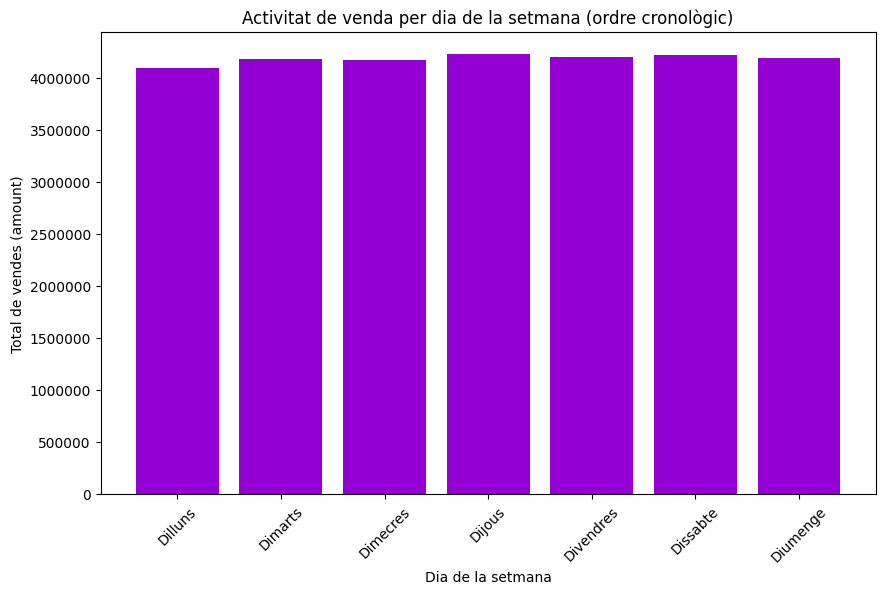

In [31]:
ordre_dies = ["Dilluns", "Dimarts", "Dimecres", "Dijous", "Divendres", "Dissabte", "Diumenge"]
df_dies = df_dies.set_index("dia_setmana").loc[ordre_dies].reset_index()

plt.figure(figsize=(10, 6))
plt.bar(df_dies["dia_setmana"], df_dies["amount"], color="darkviolet")
plt.xlabel("Dia de la setmana")
plt.ylabel("Total de vendes (amount)")
plt.title("Activitat de venda per dia de la setmana (ordre cronològic)")
plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="y")
plt.show()

#### Anàlisi de la concentració de vendes al llarg de la setmana
Per determinar si existeixen dies amb una concentració destacada d'activitat comercial, s'analitza el volum total de vendes generat en cada dia de la setmana. L'objectiu és identificar si el comportament dels clients segueix algun patró temporal o si, per contra, la demanda és estable al llarg del cicle setmanal.

Els resultats mostren que els imports diaris són molt similars entre si. El dia amb més activitat és **dijous**, amb uns 4,23 milions d'euros, seguit molt de prop per **dissabte** i **divendres**. En l'extrem inferior, **dilluns** registra aproximadament 4,09 milions. Tot i aquesta diferència, la variació entre el dia de màxima i mínima activitat és inferior al **3%**, fet que indica una distribució molt equilibrada.

El gràfic de barres permet visualitzar aquesta realitat de manera clara: les barres tenen pràcticament la mateixa altura, i això fa evident que **no hi ha cap dia que concentri de manera significativa les vendes**. La setmana presenta un comportament comercial estable, sense pics pronunciats que indiquin un dia especialment fort o dèbil.

Per tant, es pot concloure que la demanda és **altament uniforme** al llarg de la setmana. Tot i que dijous és lleugerament superior, la diferència és tan reduïda que no es pot considerar una concentració real d'activitat. Això implica que el flux de clients és estable i que les operacions comercials no depenen de manera significativa del dia de la setmana. Qualsevol decisió estratègica (personal, promocions, logística) hauria de basar-se en altres variables, ja que el calendari setmanal no genera pics ni valls rellevants.



#### 4. Quins dies de la setmana es concentra més activitat de venda? (Versió IA)

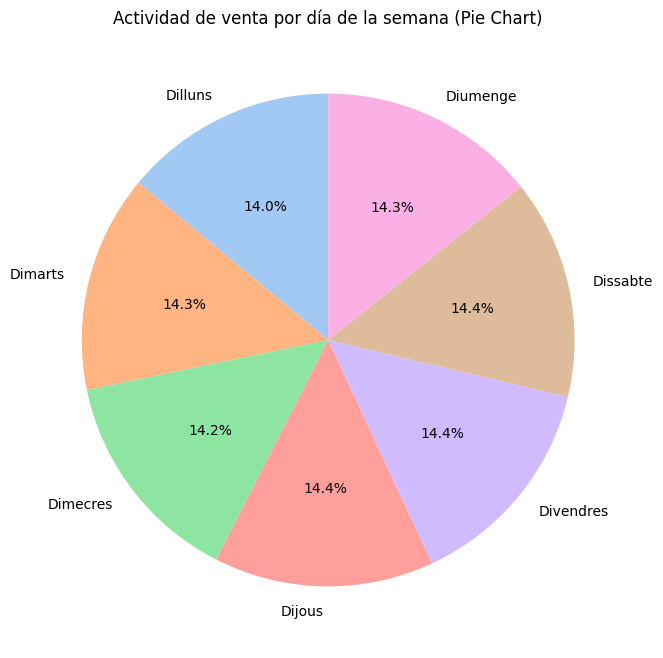

In [32]:
plt.figure(figsize=(8, 8))
plt.pie(df_dies["amount"], labels=df_dies["dia_setmana"], autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
plt.title("Actividad de venta por día de la semana (Pie Chart)")
plt.show()

#### Comparació entre el gràfic de barres i el gràfic de sectors (proposat per la IA)
La IA (Gemini) ha representat la distribució de vendes setmanals mitjançant un gràfic de sectors (pie chart), en contrast amb el gràfic de barres utilitzat en la visualització inicial.

Mentre que el gràfic de barres mostra els **valors absoluts** de cada dia, el pie chart converteix aquests imports en **percentatges** sobre el total setmanal. Això implica que la lectura del gràfic circular se centra en la proporció relativa de cada dia, i no en la magnitud exacta de les vendes.

Tot i que ambdós gràfics transmeten la idea d'una distribució equilibrada, el gràfic de barres facilita una percepció més precisa de les petites diferències entre dies, ja que permet comparar visualment les magnituds de manera directa. En canvi, el pie chart reforça la sensació d'un repartiment uniforme: les porcions són gairebé idèntiques i les diferències menors queden pràcticament imperceptibles en format percentual.

Des d'un punt de vista pedagògic, el gràfic de barres és més adequat per analitzar i quantificar diferències, mentre que el gràfic de sectors és útil per comunicar de manera intuïtiva la idea d'equilibri en la distribució.  
En conjunt, la proposta de la IA no suposa una millora substancial, però sí una **variant estètica** que pot resultar útil en contextos on es vulgui destacar visualment la uniformitat de les vendes al llarg de la setmana.

---


## Exercici 2: Preguntes analítiques complexes (amb guia)

**🌍 Context:** Aquest exercici requereix combinar informació de diverses taules del model per poder respondre correctament les preguntes.
Aquí sí que serà necessari:

» Fer merge entre taules.

» Utilitzar groupby, pivot_table, crosstab...

» Aplicar agregacions, transformacions intermèdies i funcions.

<br>

Preguntes analítiques (amb guia general)

» Depenem excessivament d'un nombre reduït de països de companyies venedores?

Passos orientatius:

1. Combinar la informació de transaccions amb la de companyies.

2. Agrupar la facturació per país.

3. Calcular la facturació total generada per cada país.

4. Ordenar els països de major a menor facturació.

5. Calcular el percentatge acumulat sobre el total.

6. Visualitzar.
<br>

» Existeix estacionalitat en les vendes?

Passos orientatius:

1. Treballar amb dates de transacció.

2. Extreure la informació temporal rellevant (any i mes).

3. Calcular el volum total de vendes (suma de amount) per any i mes.

4. Comparar patrons temporals amb la comparació entre anys. Crea una taula tipus pivot.

5. Visualitzar l'evolució.
<br>

» Anàlisi de concentració i variabilitat (tria UNA opció)

- Opció A - Producte (Només si disposes de la taula de productes)

      Quins productes generen més ingressos i amb quina variabilitat?

    Passos orientatius:

    1. Combinar transaccions, la taula pont i productes.

    2. Calcular ingressos per producte amb un groupby, sum y sort.

    3. Selecciona els top N productes: 15 per exemple.

    4. Escollir una visualització adequada per analitzar dispersió.

- Opció B - Activitat d'usuaris (Alternativa si no disposes de la taula de productes)

      Hi ha usuaris que han deixat de comprar recentment?

    Passos orientatius:

    1. Identificar l'última compra per usuari.

    2. Calcular el temps des de l'última compra.

    3. Visualitzar la distribució del temps des de l'última compra.
<br>

» Com varia l'activitat de venda per franges horàries al llarg dels anys? (patrons horaris)

Passos orientatius:

1. Crear franges horàries a partir de l'hora: crea una funció i aplica-la utilitzant apply.

2. Construir una taula agregada utilitzant crosstab.

3. Visualitzar amb un heatmap.
<br>

👉 Per a cada pregunta:

» Descriu breument els passos seguits.

» Mostra la visualització final.

» Interpreta què implica per al negoci.

---
### Depenem excessivament d'un nombre reduït de països de companyies venedores?

Una empresa que opera amb companyies venedores repartides per diversos països necessita saber fins a quin punt els seus ingressos depenen d'uns pocs mercats concrets. Si la facturació es concentra excessivament en dos o tres països, el negoci queda exposat a riscos externs (canvis normatius, crisis econòmiques locals, variacions de la demanda) que podrien afectar de manera desproporcionada els resultats globals.

En aquest exercici es combinarà la informació de transaccions amb la de les companyies venedores per calcular quina facturació aporta cada país i s'analitzarà el grau de concentració. L'objectiu és respondre a una pregunta clau per a la presa de decisions: **depenem excessivament d'un nombre reduït de països?**

S'importa `companies_df`, amb la informació de les companyies venedores (país, nom, etc). Es genera una copia de 'df_transactions' per treballar amb un df net.

In [33]:
from google.colab import files
uploaded = files.upload()
companies_df = pd.read_csv(list(uploaded.keys())[0])

Saving companies.csv to companies.csv


In [34]:
transactions_n1ex2 = df_transactions.copy()

Les transaccions identifiquen la companyia mitjançant `company_id`, però no el seu país. Es realitza un merge amb `companies_df` per incorporar el país a cada transacció i així poder agregar la facturació geogràficament.

In [35]:
transactions_companies_df = transactions_n1ex2.merge(companies_df[["company_id", "country"]], on="company_id", how="left")

Es descarten les transaccions declinades (`declined == 1`), ja que corresponen a intents de compra que no es van completar i no representen ingrés real.

In [36]:
transactions_companies_df = transactions_companies_df[transactions_companies_df["declined"] == 0]

Amb les transaccions vàlides, s'agrupa per país i es suma l'import per obtenir la facturació total generada per cadascun, ordenant de major a menor per identificar els mercats més rellevants.

In [37]:
facturacio_pais_df = (transactions_companies_df.groupby("country")["amount"].sum().reset_index().sort_values(by="amount", ascending=False))

Es calcula quin percentatge representa cada país sobre el total facturat, i s'acumulen els valors. Això permetrà saber, per exemple, quants països calen per explicar el 80% de la facturació total (anàlisi tipus Pareto).

In [38]:
total_amount = facturacio_pais_df["amount"].sum()
facturacio_pais_df["percentage"] = facturacio_pais_df["amount"] / total_amount * 100
facturacio_pais_df["cumulative_percentage"] = facturacio_pais_df["percentage"].cumsum()

Abans de visualitzar el gràfic, es fa una ullada als números concrets: quant factura cada país i quin pes té sobre el total acumulat. Això servirà de referència per interpretar amb precisió el gràfic que ve a continuació.

In [39]:
facturacio_pais_df.set_index("country")

,amount,percentage,cumulative_percentage
country,,,
Sweden,4884250.39,16.827514,16.827514
Netherlands,4470873.59,15.403324,32.230838
United Kingdom,4065098.37,14.005322,46.236160
Italy,4061060.93,13.991412,60.227573
Germany,3984664.03,13.728205,73.955778
France,1406668.15,4.846338,78.802116
United States,1085266.88,3.739027,82.541143
Belgium,937789.26,3.230928,85.772071
Norway,798331.87,2.750461,88.522532


Es representa la facturació per país (barres) juntament amb el percentatge acumulat (línia), per identificar visualment si el negoci depèn d'un grup reduït de països o si la facturació està repartida de forma més equilibrada.

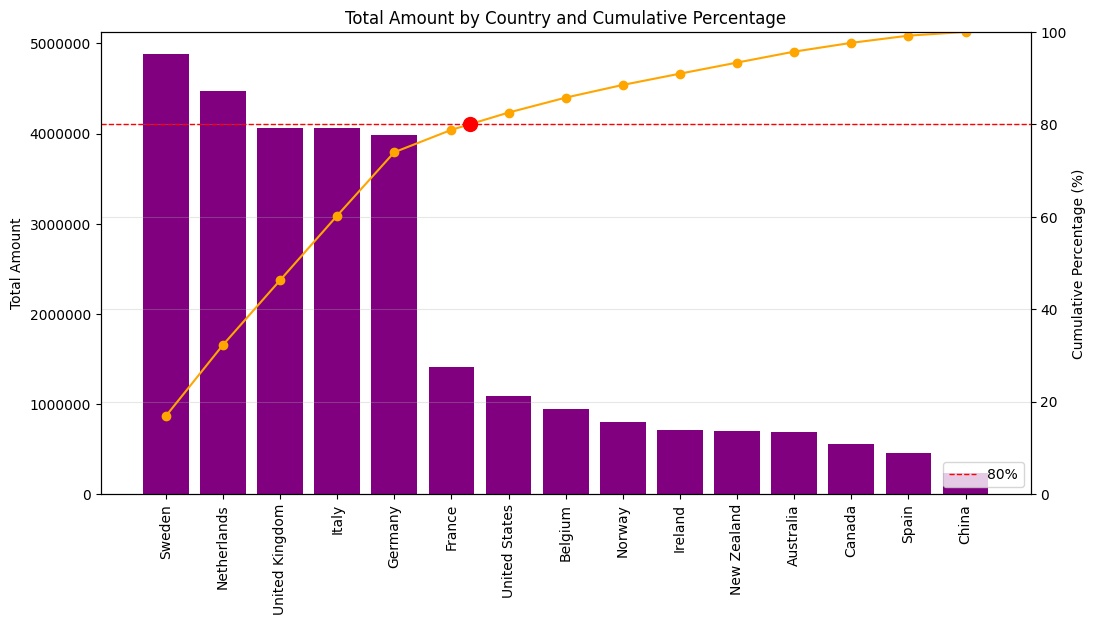

In [40]:
plt.figure(figsize=(12,6))
plt.bar(facturacio_pais_df["country"], facturacio_pais_df["amount"], color="purple")
plt.xticks(rotation=90)
plt.ylabel("Total Amount")
plt.ticklabel_format(style='plain', axis='y')

ax2 = plt.twinx()
ax2.plot(facturacio_pais_df["country"], facturacio_pais_df["cumulative_percentage"], color="orange", marker="o")
ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 100)

ax2.axhline(80, color="red", linestyle="--", linewidth=1, label="80%")

idx_despres = facturacio_pais_df[facturacio_pais_df["cumulative_percentage"] >= 80].index[0]
pos_despres = facturacio_pais_df.index.get_loc(idx_despres)
pos_abans = pos_despres - 1

y_abans = facturacio_pais_df.iloc[pos_abans]["cumulative_percentage"]
y_despres = facturacio_pais_df.iloc[pos_despres]["cumulative_percentage"]

frac = (80 - y_abans) / (y_despres - y_abans)
x_creuament = pos_abans + frac

ax2.plot(x_creuament, 80, marker="o", markersize=10, color="red", zorder=5)

ax2.legend(loc="lower right")
plt.title("Total Amount by Country and Cumulative Percentage")
plt.grid(axis="y", alpha=0.3)
plt.show()

La facturació està clarament concentrada en un grup reduït de països: **5 mercats (Suècia, Països Baixos, Regne Unit, Itàlia i Alemanya) sumen gairebé el 74% de la facturació total**, i calen només 6 països per superar el llindar del 80% (amb l'entrada dels Estats Units). La resta de països (9 en total) aporten conjuntament menys del 18% dels ingressos.

Aquesta concentració implica una dependència significativa d'un grup molt reduït de mercats europeus/occidentals. Qualsevol canvi normatiu, econòmic o de demanda en algun d'aquests 5-6 països clau (especialment Suècia i Països Baixos, que per si sols ja sumen més del 32%) tindria un impacte molt notable en la facturació global del negoci. Es recomanaria vigilar de prop l'evolució d'aquests mercats i valorar estratègies de diversificació cap a països amb menys pes actual, per reduir aquest risc de concentració.

---
### Existeix estacionalitat en les vendes?

Moltes empreses tenen patrons de venda que es repeteixen any rere any: pics en època nadalenca, caigudes a l'estiu, campanyes puntuals, etc. Detectar aquesta estacionalitat és clau per prendre decisions com planificar estoc, dimensionar l'equip o llançar campanyes de màrqueting en el moment adequat.

En aquest exercici s'anaitzarà com evoluciona el volum de vendes al llarg del temps, comparant el comportament mes a mes entre diferents anys, per identificar si existeixen patrons que es repeteixen de forma consistent.

Es converteix la columna `event_time` a format de data (`datetime`), ja que actualment és text. Això permetrà extreure'n l'any i el mes per analitzar l'evolució temporal de les vendes.

In [41]:
transactions_n1ex2["event_time"] = pd.to_datetime(transactions_n1ex2["event_time"])

Es descarten les transaccions amb `declined == 1`, ja que corresponen a intents de compra que no es van completar i no representen ingrés real. Es treballarà només amb transaccions vàlides per obtenir una imatge fidel del volum de vendes.

In [42]:
transactions_val = transactions_n1ex2.copy()
transactions_val = transactions_val[transactions_val["declined"] == 0].copy()

A partir de la data de cada transacció, separem l'any i el mes en columnes pròpies. Això ens permetrà agrupar i comparar el volum de vendes en aquestes dues dimensions temporals.

In [43]:
transactions_val["year"] = transactions_val["event_time"].dt.year
transactions_val["month"] = transactions_val["event_time"].dt.month

Es suma l'import de totes les transaccions agrupant-les per any i mes, per obtenir el volum total de vendes generat en cada període.

In [44]:
vendes_mensuals = transactions_val.groupby(["year", "month"])["amount"].sum().reset_index()

Es reorganitzen les dades en una taula pivot (mesos com a files, anys com a columnes) per poder comparar visualment el comportament de cada mes al llarg dels diferents anys d'un cop d'ull.

In [45]:
taula_pivot = vendes_mensuals.pivot_table(index="month", columns="year", values="amount")
taula_pivot

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
month,,,,,,,,,,
1,221978.21,224451.27,222956.21,227411.90,222944.11,231702.95,243339.85,224709.53,228413.66,226393.73
2,245780.13,248112.42,252303.71,245092.09,259807.32,248318.04,257434.31,235427.85,251422.67,249898.07
3,253000.65,246634.37,237621.09,237099.83,276818.21,258872.56,250861.14,271978.12,241711.00,245792.02
4,245597.21,240833.04,251596.72,234246.30,242707.81,244251.90,259770.51,237165.49,241264.06,244769.15
5,248585.36,241306.84,240125.80,244448.97,242550.42,253699.74,239662.08,276262.60,261355.45,254122.62
6,232624.35,230577.43,240337.61,242769.22,241694.85,236410.96,234080.71,260082.37,232254.56,244370.81
7,241252.27,237081.73,240576.35,231261.73,233513.25,240255.64,251450.91,233349.01,238652.72,230031.53
8,233797.97,235600.88,230225.76,228759.89,237070.53,232658.86,237051.75,245198.95,237981.15,236671.63
9,227211.93,241530.84,230606.28,236768.38,232551.83,257964.96,245398.37,254316.72,234226.30,234226.89


Es representa el volum de vendes de cada any com una línia independent, per detectar si els mesos segueixen un comportament similar (pujades i baixades en els mateixos moments) any rere any.

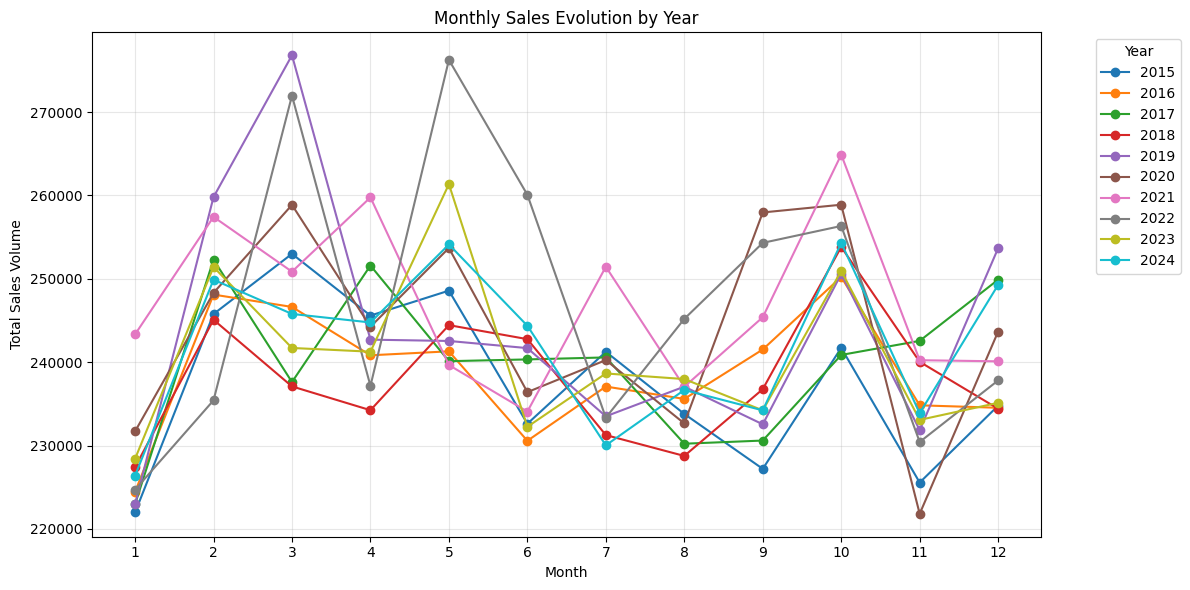

In [46]:
taula_pivot.plot(kind="line", marker="o", figsize=(12,6))
plt.title("Monthly Sales Evolution by Year")
plt.xlabel("Month")
plt.ylabel("Total Sales Volume")
plt.xticks(range(1,13))
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El gràfic per anys mostra moltes línies superposades, cosa que dificulta distingir si hi ha un patró real o només soroll. Per confirmar-ho, es calcula la mitjana de vendes de cada mes a través de tots els anys, juntament amb la seva desviació estàndard. Si l'amplitud del patró mensual és clarament més gran que la variabilitat normal entre anys, es pot afirmar amb confiança que existeix una estacionalitat real.

In [47]:
mitjana_mensual = taula_pivot.mean(axis=1)
desviacio_mensual = taula_pivot.std(axis=1)

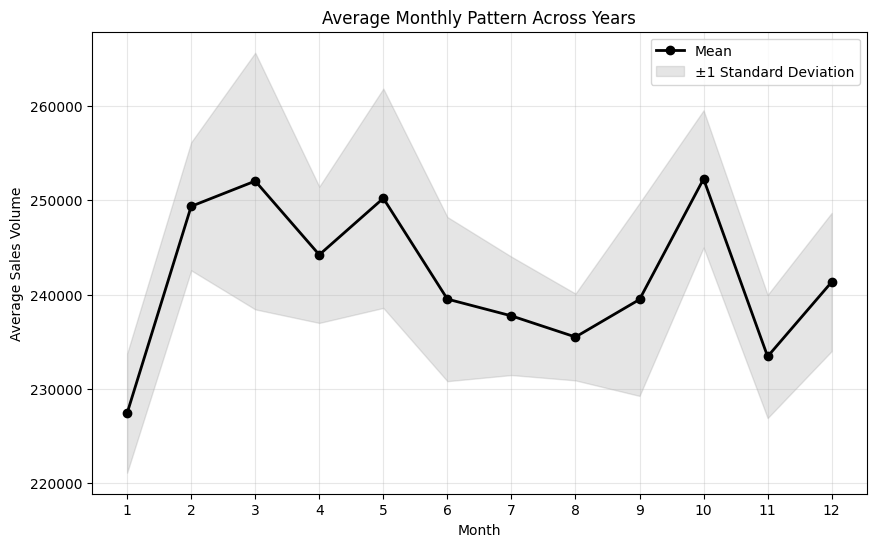

In [48]:
plt.figure(figsize=(10,6))
plt.plot(mitjana_mensual.index, mitjana_mensual.values, marker="o", color="black", linewidth=2, label="Mean")
plt.fill_between(mitjana_mensual.index, mitjana_mensual - desviacio_mensual, mitjana_mensual + desviacio_mensual, alpha=0.2, color="gray", label="±1 Standard Deviation")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Average Sales Volume")
plt.title("Average Monthly Pattern Across Years")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Contràriament a una primera impressió visual del gràfic per anys (on el soroll de moltes línies superposades dificultava veure-hi un patró clar), en calcular la mitjana mensual a través de tots els anys s'observa una estacionalitat consistent i moderada. L'amplitud del patró (uns 25.000 punts entre el mes més fort i el més feble) supera clarament la variabilitat normal any rere any en la majoria de mesos, cosa que confirma que no es tracta de soroll aleatori.

El patró identificat mostra **gener i novembre com els mesos sistemàticament més febles**, mentre que **març, maig i octubre destaquen consistentment per sobre de la mitjana** any rere any. Els mesos d'estiu (juny-agost) es mantenen en una zona baixa i estable.

Aquest patró, tot i ser menys pronunciat que una estacionalitat clàssica (com un pic nadalenc), és rellevant per a la planificació operativa: convé reforçar recursos (estoc, personal, capacitat) de cara a març, maig i octubre, i es pot aprofitar gener i novembre —mesos de menor activitat— per tasques de manteniment, formació o planificació interna amb menys pressió comercial.

---
### Quins productes generen més ingressos i amb quina variabilitat?

No tots els productes contribueixen igual als ingressos d'un negoci, ni ho fan de la mateixa manera: alguns generen vendes molt constants mes a mes, mentre que d'altres depenen de pics puntuals més difícils de preveure. Conèixer aquesta diferència és clau per prendre decisions d'estoc, producció i planificació comercial.

En aquest exercici es combinarà la informació de transaccions, la taula pont de productes-transaccions i el catàleg de productes per identificar quins són els productes que generen més ingressos, i s'analitzarà si aquest èxit es basa en una demanda estable o en una demanda irregular.

S'importa el catàleg de productes i la taula pont que relaciona cada transacció amb els productes que conté, alhora que es realitza una còpia del dataframe.

In [49]:
from google.colab import files
uploaded = files.upload()
products_df = pd.read_csv(list(uploaded.keys())[0])

Saving products.csv to products.csv


In [50]:
from google.colab import files
uploaded = files.upload()
taula_pont_df = pd.read_csv(list(uploaded.keys())[0])

Saving transactions_products.csv to transactions_products.csv


In [51]:
transactions_copy = transactions_n1ex2.copy()

Es filtren les transaccions rebutjades (`declined == 1`), ja que no representen vendes reals i no haurien de comptar en l'anàlisi d'ingressos.

In [52]:
transactions_ok = transactions_copy[transactions_copy["declined"] == 0].copy()

Cada transacció pot incloure diversos productes, informació que es troba a la taula pont. Es combinen les transaccions vàlides amb aquesta taula per obtenir una fila per cada producte venut dins de cada transacció.

In [53]:
fusio = transactions_ok.merge(taula_pont_df, on="operation_id", how="inner")

S'afegeix les dades del catàleg de productes (nom, preu, categoria, entre d'altres) a cada línia de venda, per poder identificar i analitzar els productes pel seu nom i preu real.

In [54]:
df_tran_prod = fusio.merge(products_df, on="product_id", how="inner")

Es considera que els ingressos generats per cada venda d'un producte corresponen al seu preu de catàleg. Com que cada aparició d'un producte a `df_tran_prod` representa una unitat venuda, sumar aquest valor per producte reportarà els ingressos totals que ha generat.

In [55]:
df_tran_prod["revenue"] = df_tran_prod["price"]

S'agrupa per producte (identificat pel seu `product_id`, per evitar confondre productes diferents que puguin compartir nom) i es sumen els ingressos generats per totes les seves vendes, ordenant de major a menor.

In [56]:
ingressos_producte = (df_tran_prod.groupby(["product_id", "product_name"])["revenue"].sum().sort_values(ascending=False))

Es seleccionen els 15 productes que generen més ingressos, que seran la base de la resta de l'anàlisi.

In [57]:
top15 = ingressos_producte.head(15)
df_top15 = top15.reset_index()
df_top15.columns = ["product_id", "product_name", "revenue"]
df_top15

,product_id,product_name,revenue
0,39,warden,499687.65
1,64,Direwolf,497852.90
2,67,Winterfell,494748.50
3,15,Stannis warden,486696.45
4,93,Littlefinger Tarly Stark,484389.00
5,62,the duel,476317.74
6,86,Stark kingsblood,473971.05
7,63,Jade tatooine dooku,472204.32
8,16,the duel warden,467290.53
9,12,duel Direwolf,459629.60


Els ingressos totals no expliquen tota la història: dos productes poden generar la mateixa facturació però amb comportaments molt diferents (venda constant vs. venda irregular amb pics puntuals). Per mesurar-ho, es calcula quantes unitats es venen cada mes de cada producte i s'obté el coeficient de variació (desviació estàndard entre la mitjana): un valor baix indica una demanda estable i predictible, un valor alt indica una demanda més irregular.

In [58]:
df_tran_prod["event_time"] = pd.to_datetime(df_tran_prod["event_time"])
df_tran_prod["year_month"] = df_tran_prod["event_time"].dt.to_period("M")
top15_ids = df_top15["product_id"]
vendes_mensuals_producte = (df_tran_prod[df_tran_prod["product_id"].isin(top15_ids)].groupby(["product_id", "product_name", "year_month"]).size().reset_index(name="units_sold"))
stats_producte = vendes_mensuals_producte.groupby("product_name")["units_sold"].agg(["mean", "std"])
stats_producte["cv"] = stats_producte["std"] / stats_producte["mean"]

Es visualitza conjuntament els ingressos totals (barres) i el coeficient de variació de la demanda mensual (línia) per als 15 productes principals, mantenint el mateix ordre (de més a menys ingrés) als dos eixos. Això permet identificar si els productes més rendibles ho són gràcies a una demanda estable, o si amaguen una variabilitat que convé tenir en compte.

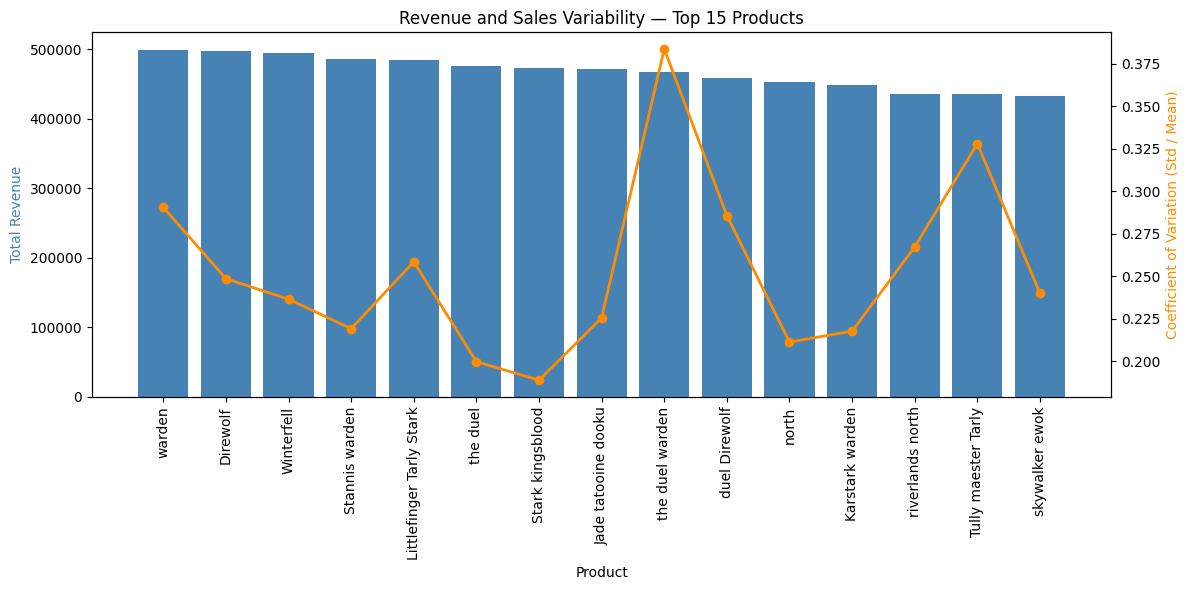

In [59]:
df_combined = df_top15.merge(stats_producte[["cv"]], on="product_name")
df_combined = df_combined.sort_values("revenue", ascending=False)
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(df_combined["product_name"], df_combined["revenue"], color="steelblue")
ax1.set_xlabel("Product")
ax1.set_ylabel("Total Revenue", color="steelblue")
ax1.tick_params(axis="x", rotation=90)
ax2 = ax1.twinx()
ax2.plot(df_combined["product_name"], df_combined["cv"], color="darkorange", marker="o", linewidth=2)
ax2.set_ylabel("Coefficient of Variation (Std / Mean)", color="darkorange")
plt.title("Revenue and Sales Variability — Top 15 Products")
plt.tight_layout()
plt.show()

Els 15 productes amb més ingressos generen entre 433.678 € i 499.688 € cadascun, una diferència relativament petita entre el primer ("warden") i el darrer del top 15 ("skywalker ewok"). No hi ha un únic producte estrella molt per damunt de la resta, sinó un grup ampli de productes similarment rellevants.

On sí apareixen diferències notables és en l'estabilitat de la demanda. **"the duel warden"** combina un ingrés elevat (467.291 €) amb la variabilitat més alta de tot el top 15, seguit de **"Tully maester Tarly"**. En canvi, **"Stark kingsblood"** i **"Stannis warden"** generen ingressos igualment alts (473.971 € i 486.696 € respectivament) amb una variabilitat molt més baixa, és a dir, una demanda molt més predictible.

Aquesta diferència és rellevant per a la gestió de l'empresa: productes com **"Stark kingsblood"** permeten una planificació d'estoc molt ajustada, amb poc risc. En canvi, productes com **"the duel warden"**, tot i generar ingressos similars, requereixen un marge de seguretat més ampli en l'estoc (o una revisió del que causa aquesta irregularitat: campanyes puntuals, estacionalitat pròpia del producte, etc.) per evitar tant ruptures d'estoc en els mesos forts com sobreproducció en els mesos febles.

### Com varia l'activitat de venda per franges horàries al llarg dels anys?

Saber a quines hores del dia compren més els clients és clau per prendre decisions operatives: quan reforçar l'atenció al client, quan programar campanyes o manteniments, o si cal adaptar l'operativa a diferents zones horàries. En aquest exercici s'analitzarà com es distribueix el nombre de transaccions entre quatre franges horàries (matinada, matí, tarda i vespre) i si aquest patró es manté consistent al llarg dels anys.

Es realitza una còpia de les transaccions, es descarten les rebutjades (no representen activitat de venda real) i es converteix `event_time` a format `datetime` per poder-ne extreure l'hora.

In [60]:
transactions_activitat = transactions_n1ex2.copy()
transactions_n = transactions_activitat[transactions_activitat["declined"] == 0].copy()
transactions_n["event_time"] = pd.to_datetime(transactions_n["event_time"])

Es defineixen quatre franges horàries (matinada (night), matí (morning), tarda (afternoon) i vespre (evening)) i s'apliquen a cada transacció a partir de la seva hora, juntament amb l'any corresponent. Això permetrà agregar l'activitat de venda per any i franja horària.

In [61]:
def franja_horaria(hora):
    if 0 <= hora < 6:
        return "Night (00-06h)"
    elif 6 <= hora < 12:
        return "Morning (06-12h)"
    elif 12 <= hora < 18:
        return "Afternoon (12-18h)"
    else:
        return "Evening (18-24h)"

transactions_n["hour"] = transactions_n["event_time"].dt.hour
transactions_n["time_slot"] = transactions_n["hour"].apply(franja_horaria)
transactions_n["year"] = transactions_n["event_time"].dt.year

Es construeix una taula agregada que compta el nombre de transaccions per a cada combinació d'any i franja horària, ordenant les columnes de manera cronològica (nit → vespre) per facilitar-ne la lectura.

In [62]:
taula_agregada = pd.crosstab(transactions_n["year"], transactions_n["time_slot"])
ordre_franges = ["Night (00-06h)", "Morning (06-12h)", "Afternoon (12-18h)", "Evening (18-24h)"]
taula_agregada = taula_agregada[ordre_franges]
taula_agregada

time_slot,Night (00-06h),Morning (06-12h),Afternoon (12-18h),Evening (18-24h)
year,,,,
2015,2431,2443,2425,2478
2016,2454,2461,2481,2374
2017,2425,2456,2531,2421
2018,2496,2410,2487,2430
2019,2437,2536,2526,2429
2020,2591,2445,2453,2520
2021,2569,2555,2569,2505
2022,2548,2431,2497,2539
2023,2492,2528,2448,2434


Es representa la taula amb un mapa de calor, on cada cel·la mostra el nombre de transaccions d'aquell any i franja horària. Els colors més intensos indiquen més activitat, cosa que permet detectar visualment si hi ha franges o anys amb un comportament clarament diferent.

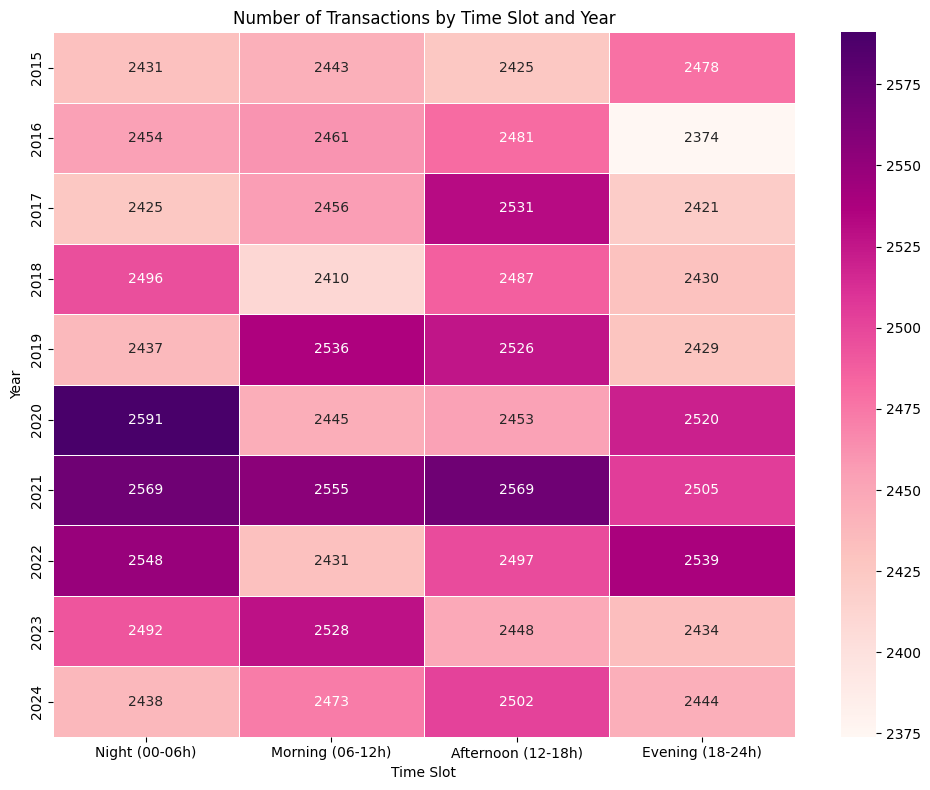

In [63]:
plt.figure(figsize=(10,8))
sns.heatmap(taula_agregada, annot=True, fmt="d", cmap="RdPu", linewidths=0.5)
plt.title("Number of Transactions by Time Slot and Year")
plt.xlabel("Time Slot")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

L'activitat de venda es manté molt estable al llarg del dia i dels anys: tots els valors del mapa de calor es mouen en una franja molt estreta (entre 2.374 i 2.591 transaccions), sense que cap franja horària concreta (matinada, matí, tarda o vespre) destaqui de manera consistent per sobre o per sota de la resta any rere any. Els tons de color, molt similars entre si, confirmen visualment aquesta manca de patró marcat.

Aquest resultat és coherent amb el que ja s'havia observat a l'anàlisi d'estacionalitat mensual: el negoci presenta un volum d'activitat molt homogeni, sense pics ni valls horaris ni estacionals forts. Des del punt de vista operatiu, això és una bona notícia per a la planificació de recursos (atenció al client, capacitat de processament, etc), ja que no cal reforçar especialment cap franja horària concreta per sobre de les altres: la demanda es reparteix de manera consistent i predictible al llarg de tot el dia i de tot l'any.

---
---
# Nivell 2 - Anàlisi relacional i patrons avançats

#### Càrrega de l'arxiu CSV
Per poder realitzar els anàlisis pertinents, es realitza una còpia de `df_transactions`,  corresponent a la taula `Transactions`.

Aquesta taula serà la base de totes les preguntes analítiques del nivell.

In [64]:
df_transactions2 = df_transactions.copy()

## Exercici 1: Anàlisi de productes i captació d'usuaris

**🎯 Objectiu:** Analitzar el rendiment dels productes combinant ingressos, estabilitat i capacitat de captació de nous usuaris, amb l'objectiu de detectar possibles riscos de negoci associats a concentració excessiva d'ingressos, dependència d'usuaris recurrents i manca de creixement en base d'usuaris.

<br>

Els productes que generen més ingressos també impulsen el creixement del negoci mitjançant la captació de nous usuaris, o bé el negoci depèn principalment d'usuaris recurrents comprant els mateixos productes?

Passos orientatius:

1. Combina les taules necessàries.

2. Defineix un criteri de nou usuari si la transacció analitzada és la primera cronològicament que realitza al sistema es_nou_usuari = True / False.

3. Agrega la informació per producte i calcula les mètriques següents:

    - Ingressos totals.
    - Variabilitat dels ingressos.
    - Nombre de nous usuaris.
    - Percentatge de nous usuaris sobre el total de compradors del producte.
4. Creació d'una tipologia analítica de productes a partir de les mètriques calculades, per exemple:

    - Captador: alta captació de nous usuaris.
    - Recurrent: ingressos elevats però baixa captació.
    - Emergent: baixa facturació però bona captació.
    - Estancat: baixos ingressos i baixa captació.
5. Construeix una visualització que permeti analitzar la relació entre les dimensions principals. Per exemple, un scatter plot amb:

    - Eix X → ingressos totals per producte.
    - Eix Y → nombre de nous usuaris.
    - Mida del punt → variabilitat dels ingressos.
    - Color del punt → tipologia analítica del producte.

```
📌 Nota important

No es tracta només de mostrar gràfics, sinó d'interpretar què implica per al negoci no captar nous usuaris.
```

### Anàlisi de productes i captació d'usuaris

No n'hi ha prou de saber quins productes generen més ingressos: també és clau entendre si aquest èxit ve acompanyat de creixement real del negoci, és a dir, de captació de nous usuaris, o si respon principalment a compres repetides d'una base de clients que ja existeix. Un negoci que factura bé però no capta clientela nova té un risc de creixement limitat a mitjà termini.

En aquest exercici es combinarà informació de transaccions, productes i captació d'usuaris per classificar cada producte segons el seu rendiment econòmic i la seva capacitat d'atreure compradors nous, identificant possibles riscos de concentració, dependència d'usuaris recurrents o manca de creixement en la base d'usuaris.

---

S'importa el catàleg de productes i la taula pont que relaciona cada transacció amb els productes venuts, necessaris per analitzar el rendiment per producte en aquest exercici.

També es realitza una còpia de les transaccions per treballar en aquest exercici.

In [65]:
from google.colab import files
uploaded = files.upload()
df_products_n2ex1 = pd.read_csv(list(uploaded.keys())[0])

Saving products.csv to products (1).csv


In [66]:
from google.colab import files
uploaded = files.upload()
df_taula_pont_n2ex1 = pd.read_csv(list(uploaded.keys())[0])

Saving transactions_products.csv to transactions_products (1).csv


In [67]:
transactions_n2ex1 = df_transactions2.copy()

Es descarten les rebutjades (`declined == 1`), ja que no representen vendes reals ni haurien de comptar a l'hora d'identificar compradors o calcular ingressos.

In [68]:
transactions_n2ex1 = transactions_n2ex1[transactions_n2ex1["declined"] == 0].copy()

Es converteix `event_time` a format `datetime`, ja que es necessitarà per identificar cronològicament la primera compra de cada usuari.

In [69]:
transactions_n2ex1["event_time"] = pd.to_datetime(transactions_n2ex1["event_time"])

Es combinen les transaccions vàlides amb la taula pont (per saber quins productes conté cada transacció) i amb el catàleg de productes (per obtenir el nom i el preu de cadascun).

In [70]:
fusio_n2ex1 = transactions_n2ex1.merge(df_taula_pont_n2ex1, on="operation_id", how="inner")
df_n2ex1 = fusio_n2ex1.merge(df_products_n2ex1, on="product_id", how="inner")

Per a cada usuari, s'identifica quina és la seva primera transacció cronològica al sistema. Es marca aquesta transacció com a compra de "nou usuari" (`es_nou_usuari = True`). La resta de les seves compres es consideren de client recurrent.

In [71]:
primera_compra = transactions_n2ex1.groupby("user_id")["event_time"].transform("min")
transactions_n2ex1["es_nou_usuari"] = transactions_n2ex1["event_time"] == primera_compra
df_n2ex1 = df_n2ex1.merge(transactions_n2ex1[["operation_id", "es_nou_usuari"]], on="operation_id", how="left")

S'agrupa per producte per calcular els ingressos totals que genera, quants dels seus compradors són usuaris nous (segons la marca `es_nou_usuari` que s'acaba de crear) i el total de compradors. A partir d'això, s'obté el percentatge de nous usuaris sobre el total de compradors de cada producte, una mètrica clau per saber si un producte contribueix a captar clientela nova o depèn principalment d'usuaris ja existents.

In [72]:
metriques_producte = df_n2ex1.groupby(["product_id", "product_name"]).agg(ingressos_totals=("price", "sum"), nous_usuaris=("es_nou_usuari", "sum"), total_compradors=("es_nou_usuari", "count")).reset_index()
metriques_producte["pct_nous_usuaris"] = (metriques_producte["nous_usuaris"] / metriques_producte["total_compradors"] * 100)

Com que el preu és fix per producte, la variabilitat no es pot mesurar sobre el preu unitari (seria sempre constant). En lloc d'això, es calcula els ingressos que genera cada producte mes a mes i s'obté la desviació estàndard: un valor alt indica un producte amb vendes irregulars (pics puntuals), mentre que un valor baix indica una facturació estable al llarg del temps. S'uneix aquest resultat a la resta de mètriques per tenir-ho tot centralitzat en una única taula.

In [73]:
df_n2ex1["year_month"] = df_n2ex1["event_time"].dt.to_period("M")
ingressos_mensuals_producte = (df_n2ex1.groupby(["product_id", "product_name", "year_month"])["price"].sum().reset_index(name="ingressos_mes"))
variabilitat_producte = (ingressos_mensuals_producte.groupby(["product_id", "product_name"])["ingressos_mes"].std().reset_index(name="variabilitat_ingressos"))
metriques_producte = metriques_producte.merge(variabilitat_producte, on=["product_id", "product_name"])
metriques_producte

,product_id,product_name,ingressos_totals,nous_usuaris,total_compradors,pct_nous_usuaris,variabilitat_ingressos
0,1,Direwolf Stannis,394719.50,110,2450,4.489796,1045.486527
1,2,Tarly Stark,23580.48,126,2552,4.937304,51.211784
2,3,duel tourney Lannister,429022.91,126,2507,5.025927,904.391559
3,4,warden south duel,184254.07,121,2563,4.721030,500.139148
4,5,skywalker ewok,433186.60,152,2530,6.007905,813.026754
...,...,...,...,...,...,...,...
95,96,dooku solo,52007.12,99,2486,3.982301,148.501996
96,97,jinn Winterfell,164038.50,121,2514,4.813047,335.799056
97,98,Direwolf Littlefinger,97588.18,120,2546,4.713276,218.764961
98,99,the duel,378691.10,125,2495,5.010020,805.285662


Es classifica cada producte segons si els seus ingressos i el seu percentatge de captació de nous usuaris estan per sobre o per sota de la mediana del conjunt. D'aquesta manera s'obtenen quatre perfils: productes que capten bé i generen ingressos alts (*Captador*), productes rendibles però que depenen d'usuaris recurrents (*Recurrent*), productes amb bona captació però ingressos encara baixos (*Emergent*), i productes amb baix rendiment en ambdós aspectes (*Estancat*).

In [74]:
mediana_ingressos = metriques_producte["ingressos_totals"].median()
mediana_pct_nous = metriques_producte["pct_nous_usuaris"].median()

def tipologia(row):
    ingressos_alts = row["ingressos_totals"] >= mediana_ingressos
    captacio_alta = row["pct_nous_usuaris"] >= mediana_pct_nous

    if ingressos_alts and captacio_alta:
        return "Captador"
    elif ingressos_alts and not captacio_alta:
        return "Recurrent"
    elif not ingressos_alts and captacio_alta:
        return "Emergent"
    else:
        return "Estancat"

metriques_producte["tipologia"] = metriques_producte.apply(tipologia, axis=1)

Es visualitzen les estadístiques de `ingressos_totals` i `variabilitat_ingressos` per comprobar els valors bàsics (mínim, màxim, mitjana).

In [75]:
metriques_producte[["ingressos_totals", "variabilitat_ingressos"]].describe()

,ingressos_totals,variabilitat_ingressos
count,100.000000,100.000000
mean,256597.525700,542.593319
std,151136.088467,341.056332
min,5459.000000,11.374776
25%,133899.277500,249.346448
50%,248935.430000,530.595684
75%,396712.065000,807.220935
max,499687.650000,1494.761990


Es representen cadascun dels 100 productes segons quatre dimensions alhora: els ingressos totals que genera (eix X), el nombre de nous usuaris que ha captat (eix Y), la irregularitat dels seus ingressos mensuals (mida del punt) i la seva tipologia (color). Aquesta visualització permet identificar d'un cop d'ull quins productes combinen bons ingressos amb bona capacitat de captació, i quins depenen excessivament de compradors recurrents o tenen un rendiment feble en ambdós aspectes.

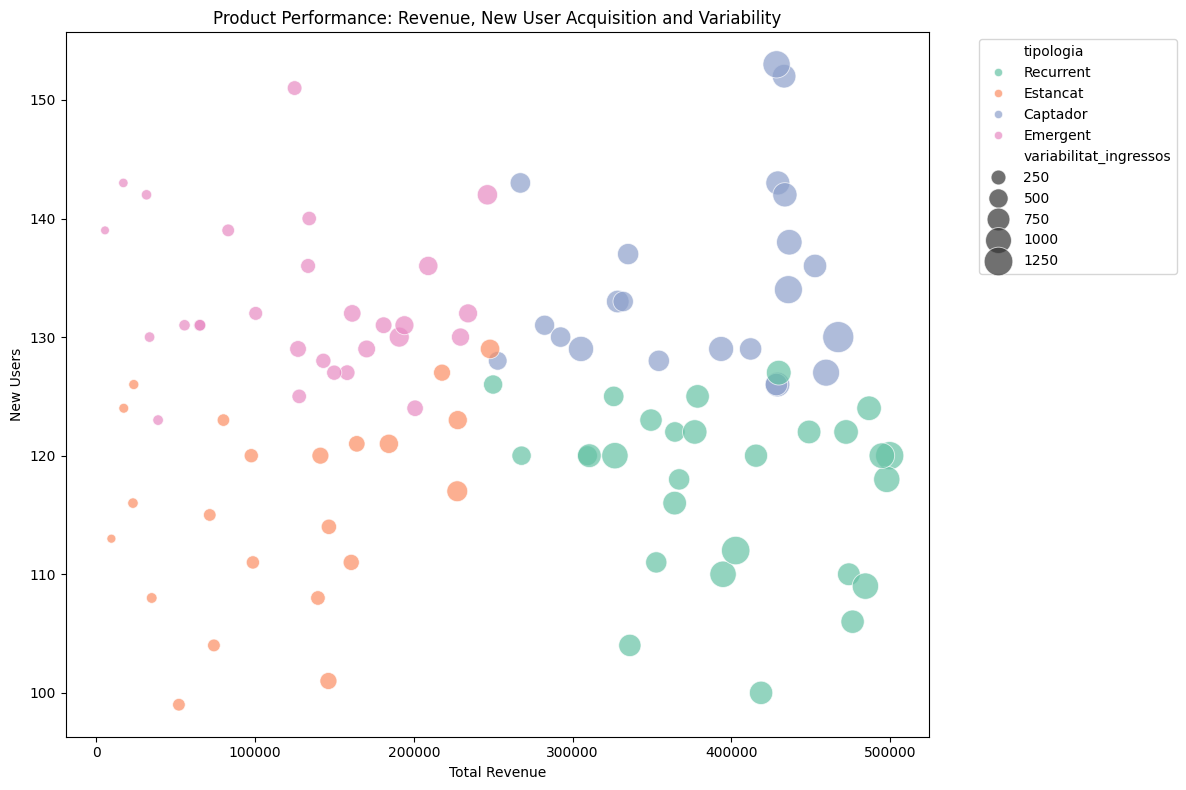

In [76]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=metriques_producte, x="ingressos_totals", y="nous_usuaris", size="variabilitat_ingressos", hue="tipologia", sizes=(40, 500), alpha=0.7, palette="Set2")
plt.xlabel("Total Revenue")
plt.ylabel("New Users")
plt.title("Product Performance: Revenue, New User Acquisition and Variability")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

Els productes es distribueixen en quatre perfils força equilibrats en volum (28 Recurrents, 28 Emergents, 22 Estancats, 22 Captadors), però amb comportaments clarament diferenciats. Els productes classificats com a **Captador** no només generen ingressos alts, sinó que ho fan captant sistemàticament més usuaris nous que els productes **Recurrent**, els quals, tot i facturar un volum similar, depenen en major mesura d'una base de clients ja existent.

Aquesta diferència és rellevant per al creixement del negoci: si la majoria del creixement en ingressos prové de productes de tipus **Recurrent**, el negoci podria estar creixent en facturació sense créixer proporcionalment en base d'usuaris, cosa que suposa un risc a mitjà termini (dependència d'una base de clients que no s'amplia). Per contra, els productes **Captador** demostren que sí és possible generar ingressos alts mentre s'atrau clientela nova, i podrien servir de referència (en categoria, preu o estratègia de màrqueting) per replicar aquest comportament en altres productes.

Pel que fa a la variabilitat dels ingressos (mida dels punts), no s'observa una relació clara amb els ingressos totals ni amb la captació: hi ha productes molt rendibles amb ingressos estables i d'altres amb ingressos molt irregulars, independentment del seu perfil. Això suggereix que la inestabilitat en la facturació és més aviat una característica pròpia de cada producte (per exemple, per campanyes puntuals) que un tret compartit per tipologia.

## Exercici 2: Anàlisi geogràfica companyia - usuari i oportunitats d'expansió

**🎯 Objectiu:** Analitzar la relació entre el país de les companyies venedores, el país de residència dels usuaris i el flux de compra entre països.

<br>

El negoci està basat en mercats locals (mateix país usuari-companyia) o hi ha una oportunitat real d'expansió internacional obrint més companyies en certs països?

Passos orientatius:

1. Combina les taules necessàries.

2. Crea una variable clau d'anàlisi: compra_local = True/False.

3. Analitza el comportament global:

    - Percentatge de transaccions locals vs internacionals.
    - Percentatge de facturació local vs internacional.
4. Anàlisi per país de l'usuari, per cada país d'usuari:

    - % de compres a companyies del mateix país.
    - % de compres a companyies estrangeres.
    - Import total comprat.
5. Anàlisi per país de companyia, per cada país de companyia calcula quina part de la seva facturació ve de:

    - Usuaris locals.
    - Usuaris estrangers.
6. Escull una visualització que expliqui clarament el fenomen.

7. Interpretació estratègica:

    - En quins països valdria la pena obrir més companyies locals?
    - Hi ha països amb demanda però poca oferta local?
    - El negoci depèn massa de companyies d'un sol país?
    - Obrir companyies locals reduiria fricció o milloraria conversió?

### Anàlisi geogràfica companyia-usuari i oportunitats d'expansió

Quan una empresa opera amb usuaris i companyies venedores repartits per diversos països, és important saber si el negoci funciona principalment amb compres locals (usuari i companyia del mateix país) o si hi ha un flux internacional significatiu. Entendre aquest patró ajuda a identificar oportunitats reals d'expansió: països amb molta demanda d'usuaris però poca oferta local de companyies.

En aquest exercici es combinarà la informació de transaccions, companyies i usuaris per analitzar el pes de les compres locals vs. internacionals, tant de manera global com per país, i valorar si obrir noves companyies en certs països podria reduir fricció o millorar la conversió.

S'importa la informació de les companyies venedores (amb el seu país) i dels usuaris (amb el seu país de residència), necessàries per analitzar el flux geogràfic de compra entre usuaris i companyies.

In [77]:
from google.colab import files
uploaded = files.upload()
df_companies_n2ex2 = pd.read_csv(list(uploaded.keys())[0])

Saving companies.csv to companies (1).csv


In [78]:
from google.colab import files
uploaded = files.upload()
df_users_n2ex2 = pd.read_csv(list(uploaded.keys())[0])

Saving users.csv to users.csv


Es parteix d'una còpia pròpia de les transaccions i es descarten les rebutjades, ja que no representen compres reals i no haurien de comptar en l'anàlisi del flux de compra entre països.

In [79]:
transactions_n2ex2 = df_transactions2.copy()
transactions_n2ex2 = transactions_n2ex2[transactions_n2ex2["declined"] == 0].copy()

S'afegeix a cada transacció el país de la companyia venedora i el país de residència de l'usuari que la realitza. Amb aquestes dues columnes disponibles, es podrà determinar si cada compra és local o internacional.

In [80]:
df_n2ex2 = transactions_n2ex2.merge(df_companies_n2ex2[["company_id", "country"]], on="company_id", how="left")
df_n2ex2 = df_n2ex2.rename(columns={"country": "company_country"})

df_n2ex2 = df_n2ex2.merge(df_users_n2ex2[["user_id", "country"]], on="user_id", how="left")
df_n2ex2 = df_n2ex2.rename(columns={"country": "user_country"})

Es crea la variable `compra_local`, que pren el valor `True` quan el país de l'usuari coincideix amb el país de la companyia venedora, i `False` en cas contrari (compra internacional). Aquesta variable és la base per a tota la resta de l'anàlisi geogràfica.

In [81]:
df_n2ex2["compra_local"] = df_n2ex2["user_country"] == df_n2ex2["company_country"]

Es calcula, a nivell de tot el negoci, quin percentatge de transaccions són locals i quin percentatge són internacionals, i es fa el mateix però mirant el volum de facturació (import total) en lloc del nombre de transaccions. Comparar totes dues mètriques és rellevant: un percentatge similar de transaccions i facturació indica un comportament homogeni, mentre que una diferència notable indicaria que un dels dos tipus de compra (local o internacional) implica tiquets de compra més grans o més petits.

In [82]:
pct_transaccions = df_n2ex2["compra_local"].value_counts(normalize=True) * 100
facturacio_local = df_n2ex2.groupby("compra_local")["amount"].sum()
pct_facturacio = facturacio_local / facturacio_local.sum() * 100

In [83]:
pct_transaccions

,proportion
compra_local,
False,88.128582
True,11.871418


In [84]:
pct_facturacio

,amount
compra_local,
False,88.109341
True,11.890659


Per a cada país d'usuari, es calcula quin percentatge de les seves compres són a companyies del mateix país (local) i quin percentatge a companyies estrangeres (internacional), juntament amb l'import total que generen. Això permet identificar en quins països els usuaris depenen gairebé exclusivament de comprar a companyies estrangeres, senyal d'una possible manca d'oferta local.

In [85]:
analisi_per_usuari = df_n2ex2.groupby("user_country").agg(pct_local=("compra_local", "mean"), import_total=("amount", "sum")).reset_index()
analisi_per_usuari["pct_local"] = analisi_per_usuari["pct_local"] * 100
analisi_per_usuari["pct_internacional"] = 100 - analisi_per_usuari["pct_local"]
analisi_per_usuari = analisi_per_usuari.sort_values("import_total", ascending=False)
analisi_per_usuari

,user_country,pct_local,import_total,pct_internacional
10,United States,18.548885,3049853.50,81.451115
9,United Kingdom,17.291427,2819917.93,82.708573
7,Spain,1.734039,2668434.76,98.265961
4,Netherlands,19.361008,2651840.50,80.638992
0,Canada,9.720670,2650339.29,90.279330
6,Portugal,0.000000,2615801.06,100.000000
3,Italy,17.107273,2585602.49,82.892727
2,Germany,16.953658,2550878.07,83.046342
5,Poland,0.000000,2491052.36,100.000000
8,Sweden,21.341766,2473822.29,78.658234


Per a cada país on hi ha companyies venedores, es calcula quin percentatge de la seva facturació prové d'usuaris locals i quin d'usuaris estrangers. Combinat amb l'anàlisi anterior (per país d'usuari), permet veure el flux complet: no només d'on ve la demanda, sinó també qui l'està cobrint actualment.

In [86]:
facturacio_companyia = df_n2ex2.groupby(["company_country", "compra_local"])["amount"].sum().unstack(fill_value=0)
facturacio_companyia.columns = ["facturacio_estrangera", "facturacio_local"]
facturacio_companyia["pct_local"] = facturacio_companyia["facturacio_local"] / (facturacio_companyia["facturacio_local"] + facturacio_companyia["facturacio_estrangera"]) * 100
facturacio_companyia["pct_estranger"] = 100 - facturacio_companyia["pct_local"]
facturacio_companyia = facturacio_companyia.reset_index().sort_values("pct_local", ascending=False)
facturacio_companyia

,company_country,facturacio_estrangera,facturacio_local,pct_local,pct_estranger
14,United States,509695.04,575571.84,53.035051,46.964949
2,Canada,297261.09,254806.44,46.154941,53.845059
13,United Kingdom,3576434.50,488663.87,12.020961,87.979039
8,Netherlands,3952457.96,518415.63,11.595399,88.404601
5,Germany,3540549.43,444114.60,11.145597,88.854403
4,France,1252902.50,153765.65,10.931196,89.068804
7,Italy,3620485.28,440575.65,10.848782,89.151218
12,Sweden,4357339.06,526911.33,10.787967,89.212033
11,Spain,404089.98,48484.18,10.712980,89.287020
0,Australia,687532.20,0.00,0.000000,100.000000


Per respondre si obrir companyies locals reduiria fricció real (i no només captaria demanda existent), es compara la taxa de rebuig (`declined`) entre compres locals i internacionals, aquest cop sobre el conjunt complet de transaccions (incloent-hi les rebutjades, que en altres passos de l'anàlisi s'excloïen). Si les compres internacionals es rebutgen amb més freqüència, això indicaria una fricció addicional (per exemple, per controls antifrau més estrictes en operacions internacionals) que una oferta local podria evitar.

In [87]:
transactions_n2ex2_raw = df_transactions2.copy()
transactions_n2ex2_raw = transactions_n2ex2_raw.merge(df_companies_n2ex2[["company_id", "country"]], on="company_id", how="left")
transactions_n2ex2_raw = transactions_n2ex2_raw.rename(columns={"country": "company_country"})
transactions_n2ex2_raw = transactions_n2ex2_raw.merge(df_users_n2ex2[["user_id", "country"]], on="user_id", how="left")
transactions_n2ex2_raw = transactions_n2ex2_raw.rename(columns={"country": "user_country"})
transactions_n2ex2_raw["compra_local"] = transactions_n2ex2_raw["user_country"] == transactions_n2ex2_raw["company_country"]
friccio_internacional = transactions_n2ex2_raw.groupby("compra_local").agg(pct_declinades=("declined", "mean")).reset_index()
friccio_internacional["pct_declinades"] = friccio_internacional["pct_declinades"] * 100
friccio_internacional

,compra_local,pct_declinades
0,False,0.898591
1,True,0.809307


Es compara el percentatge de compra local segons el país de l'usuari (esquerra) i el percentatge de facturació local segons el país de la companyia (dreta). Aquest doble punt de vista permet identificar tant els països amb usuaris desatesos localment com els països on les companyies depenen gairebé exclusivament de clients estrangers.

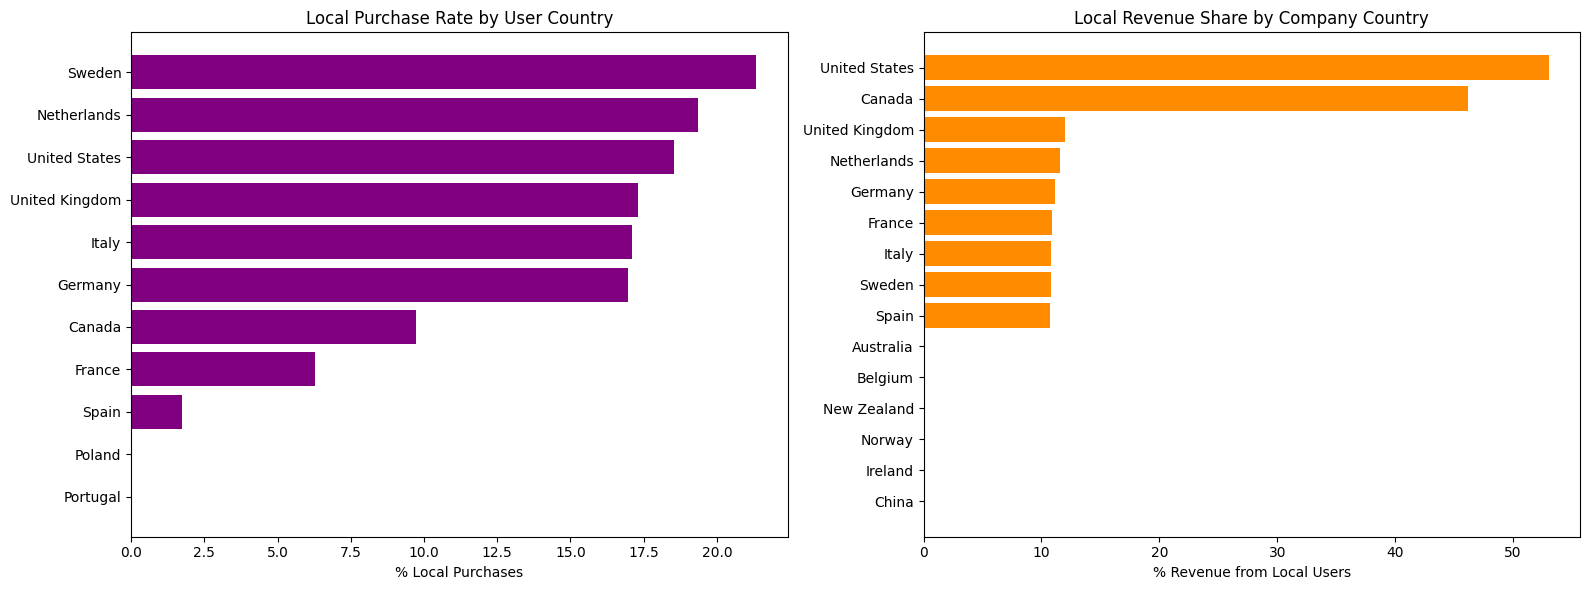

In [88]:
analisi_per_usuari_sorted = analisi_per_usuari.sort_values("pct_local", ascending=True)
facturacio_companyia_sorted = facturacio_companyia.sort_values("pct_local", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16,6), sharey=False)

axes[0].barh(analisi_per_usuari_sorted["user_country"], analisi_per_usuari_sorted["pct_local"], color="purple")
axes[0].set_xlabel("% Local Purchases")
axes[0].set_title("Local Purchase Rate by User Country")

axes[1].barh(facturacio_companyia_sorted["company_country"], facturacio_companyia_sorted["pct_local"], color="darkorange")
axes[1].set_xlabel("% Revenue from Local Users")
axes[1].set_title("Local Revenue Share by Company Country")

plt.tight_layout()
plt.show()

El negoci és marcadament internacional: només un 11,9% de les transaccions (i de la facturació) es produeixen entre usuari i companyia del mateix país. Aquest patró, però, no és homogeni i amaga oportunitats d'expansió molt clares.

Portugal i Polònia representen l'oportunitat més evident: generen una demanda significativa (2,6M € i 2,5M € en compres, entre les més altes de tots els països d'usuari) però no compten amb cap companyia local que la reculli. Tota aquesta facturació marxa cap a companyies estrangeres per pura manca d'oferta local, no per elecció dels usuaris. A més, aquesta absència d'oferta local no és neutra: les compres internacionals presenten una taxa de rebuig notablement més alta que les locals (89,9% vs. 80,9%), 9 punts percentuals de diferència. Això suggereix que comprar a l'estranger comporta una fricció addicional en el propi procés de pagament, de manera que obrir companyies locals a Portugal i Polònia no només captaria una demanda desatesa, sinó que probablement també milloraria la conversió d'aquestes compres.

En sentit contrari, Bèlgica, Noruega, Irlanda, Nova Zelanda, Austràlia i Xina tenen companyies que operen exclusivament amb clients estrangers (0% de facturació local), és a dir, són mercats on l'empresa ja ha "exportat" oferta sense tenir-hi una base d'usuaris local pròpia. Convé no descartar aquests països com a simple curiositat: tenir ja companyies establertes hi redueix bona part de la inversió inicial que sí caldria a Portugal o Polònia, així que val la pena explorar per què els usuaris locals d'aquests països no hi compren (preu, notorietat de marca, categoria de producte oferta) abans de descartar-los com a mercats de creixement. Si la manca de compra local respon a un problema resoluble (per exemple, poca visibilitat de la companyia entre els usuaris del propi país), captar-hi demanda local seria una via de creixement més barata que obrir companyies de zero, com caldria fer a Portugal o Polònia.

El cas més singular és el d'Estats Units i Canadà, únics països on una part substancial dels usuaris (53% i 46% respectivament) ja compren a companyies del seu propi país, molt per sobre del 10-12% que es repeteix a la resta de països europeus. Això suggereix que, en aquests dos mercats, el model de proximitat ja funciona i podria servir de referència per replicar en altres països.

Pel que fa a la dependència geogràfica, el negoci no depèn d'un únic país, però sí d'un grup reduït: Suècia, Països Baixos, Regne Unit, Itàlia, Alemanya i Estats Units concentren per si sols més del 80% de la facturació total. De fet, ni Portugal ni Polònia compten amb cap companyia registrada actualment, cosa que confirma que estan totalment absents d'aquesta estructura de facturació.

**Recomanació:**

Portugal i Polònia són els candidats més clars per obrir noves companyies locals, ja que combinen demanda alta, oferta local nul·la i una millora esperada en la conversió. La fricció d'expansió seria mínima perquè la demanda ja existeix.

En paral·lel, val la pena revisar l'estratègia comercial als països amb companyies locals però sense tracció local (Bèlgica, Noruega, Irlanda, Nova Zelanda, Austràlia i Xina), on el creixement podria venir més aviat d'activar la demanda local existent que d'obrir nova oferta. Totes dues vies apunten en la mateixa direcció: diversificar la base geogràfica d'ingressos del negoci, actualment molt concentrada en un grup reduït de països, reduint així el risc de dependència identificat.

---
---
# Nivell 3 - Visualització executiva i storytelling

#### Càrrega de l'arxiu CSV
Per poder realitzar els anàlisis pertinents, es realitza una còpia de `df_transactions`,  corresponent a la taula `Transactions`.

Aquesta taula serà la base de totes les preguntes analítiques del nivell.

In [89]:
df_transactions3 = df_transactions.copy()

## Exercici 1: Mini-dashboard departamental

**🎯 Objectiu:** Construeix un mini-dashboard en Python utilitzant Google Colab. Aquest exercici està pensat perquè tot el desenvolupament principal es faci dins del notebook, utilitzant Colab com a eina d'anàlisi i visualització.

<br>

L'opció principal i recomanada és la següent.

1. Figura única amb subplots (enfocament analític clàssic)

    Construcció d'una única figura amb 4 subplots utilitzant *matplotlib* i/o *seaborn*.

    Requisits:

    - 1 figura
    - 4 visualitzacions diferents
Si tens temps i vols aprofundir en una solució una mica més complexa, al final es presenten opcions avançades opcionals:

Google Colab està pensat principalment per a treball analític en notebooks. Per aquest motiu, la construcció de dashboards amb Streamlit o Dash no és recomanada dins de Colab, ja que requereix l'execució d'aplicacions web en un entorn local.

Les opcions de dashboard amb Streamlit o Dash es consideren opcions avançades i opcionals, i només s'han de desenvolupar en entorn local de Python.

2. Dashboard interactiu amb Streamlit

    Construcció d'una aplicació simple amb Streamlit, orientada a exploració interactiva.

    Requisits:

    - 1 pàgina Streamlit
    - Almenys:
      - 2 filtres
      - 3-4 visualitzacions
    - Ús de st.sidebar o selectors
3. Dashboard amb Dash

    Construcció d'un dashboard web amb Plotly Dash.

    Requisits:

    - Layout amb components.
    - Callbacks simples.
    - Almenys 3 visualitzacions connectades.

```
📌 Condició comuna a TOTES les opcions
Independentment de l'opció triada: el mini-dashboard va orientat a UN dels següents departaments:

    » Marketing.

    » Vendes / Comercial.

    » Producció.

    » Sistemes / Ciberseguretat.

Les visualitzacions han de ser:

    » Rellevants per al departament escollit.

    » Clares i llegibles.

    » Coherents entre si.

👉 No es valora la complexitat gràfica, sinó:

    » La selecció adequada de mètriques.

    » La capacitat de síntesi.

    » La coherència del missatge.
```

No tots els clients aporten el mateix valor ni es comporten igual, i Marketing necessita saber a qui dirigir els seus esforços: reforçar els segments que ja funcionen bé, o intentar reactivar aquells amb baixa activitat de compra. En aquest exercici construirem un mini-dashboard amb quatre visualitzacions que permetin identificar patrons de compra segons el perfil de l'usuari (segment, edat, país, nivell d'ingressos), amb l'objectiu de recomanar a quin tipus de client dirigir noves campanyes.

S'importa la informació dels usuaris (segment, país, edat, nivell d'ingressos, entre d'altres), necessària per segmentar el comportament de compra en aquest exercici.

In [90]:
from google.colab import files
uploaded = files.upload()
df_users_n3ex1 = pd.read_csv(list(uploaded.keys())[0])

Saving users.csv to users (1).csv


Es genera una còpia pròpia de les transaccions i es descarten les rebutjades, ja que no representen compres reals i no haurien de comptar en l'anàlisi de comportament de compra.

In [91]:
transactions_n3ex1 = df_transactions3.copy()
transactions_n3ex1 = transactions_n3ex1[transactions_n3ex1["declined"] == 0].copy()

Es combinen les transaccions amb la informació de l'usuari (segment, país, nivell d'ingressos, data de naixement) i es calcula la seva edat, per poder segmentar el comportament de compra segons aquestes característiques.

In [92]:
df_n3ex1 = transactions_n3ex1.merge(df_users_n3ex1, on="user_id", how="left")
df_n3ex1["birth_date"] = pd.to_datetime(df_n3ex1["birth_date"])
df_n3ex1["age"] = (pd.Timestamp.now() - df_n3ex1["birth_date"]).dt.days // 365

Es calcula, per a cada usuari, l'import total gastat i el nombre de compres realitzades, mantenint també el seu segment, país, nivell d'ingressos i edat. Aquesta taula serà la base per a totes les visualitzacions del dashboard.

In [93]:
volum_per_usuari = df_n3ex1.groupby("user_id").agg(total_gastat=("amount", "sum"), num_compres=("operation_id", "count"), user_segment=("user_segment", "first"), country=("country", "first"), income_band=("income_band", "first"),
  age=("age", "first")).reset_index()

Abans de construir les mètriques agregades per segment, val la pena identificar si hi ha usuaris amb una despesa molt per sobre de la resta (outliers), ja que aquests casos extrems poden requerir una estratègia diferenciada més endavant.

In [94]:
llindars_despesa = pd.DataFrame({"llindar": ["> 10.000€", "> 20.000€", "> 30.000€", "> 40.000€"], "num_usuaris": [
        (volum_per_usuari["total_gastat"] > 10000).sum(),
        (volum_per_usuari["total_gastat"] > 20000).sum(),
        (volum_per_usuari["total_gastat"] > 30000).sum(),
        (volum_per_usuari["total_gastat"] > 40000).sum()
    ]})
llindars_despesa

,llindar,num_usuaris
0,> 10.000€,186
1,> 20.000€,13
2,> 30.000€,6
3,> 40.000€,3


Es calcula, per a cada segment d'usuari, la despesa mitjana per client i el nombre d'usuaris que en formen part. Dues mètriques complementàries: la mitjana indica el valor individual de cada client d'aquest segment, mentre que el nombre d'usuaris indica el pes real del segment en el conjunt del negoci. També es construeix una taula creuada de despesa mitjana per segment i país, per poder situar geogràficament les recomanacions.

In [95]:
resum_segment = volum_per_usuari.groupby("user_segment").agg(despesa_mitjana=("total_gastat", "mean"), num_usuaris=("user_id", "count")).sort_values("despesa_mitjana", ascending=False)
pivot_segment_pais = volum_per_usuari.pivot_table(index="user_segment", columns="country", values="total_gastat", aggfunc="mean")

Es calcula la despesa mitjana creuant el segment d'usuari amb la seva franja d'edat, per identificar no només quin segment val més, sinó també a quina edat concreta dins d'aquest segment convé dirigir les campanyes.

In [96]:
bins_edat = [18, 25, 35, 45, 55, 65, 100]
labels_edat = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
volum_per_usuari["age_group"] = pd.cut(volum_per_usuari["age"], bins=bins_edat, labels=labels_edat, right=False)
pivot_segment_edat = volum_per_usuari.pivot_table(index="user_segment", columns="age_group", values="total_gastat", aggfunc="mean", observed=False)

Es construeix una única figura amb quatre visualitzacions complementàries: el creuament de despesa mitjana per país i franja d'edat (a quin país, i a quina edat, conve dirigir les campanyes), el creuament de despesa mitjana per segment i franja d'edat (a quina edat, dins de cada segment, convé dirigir-se; les línies ajuden a seguir com puja o baixa la despesa a mesura que avança l'edat dins de cada segment), la distribució completa de despesa de tots els usuaris amb els seus outliers quantificats per trams (per identificar i dimensionar el grup d'usuaris d'alt valor), i el creuament de despesa mitjana per segment i país (on dirigir les campanyes per a cada segment).

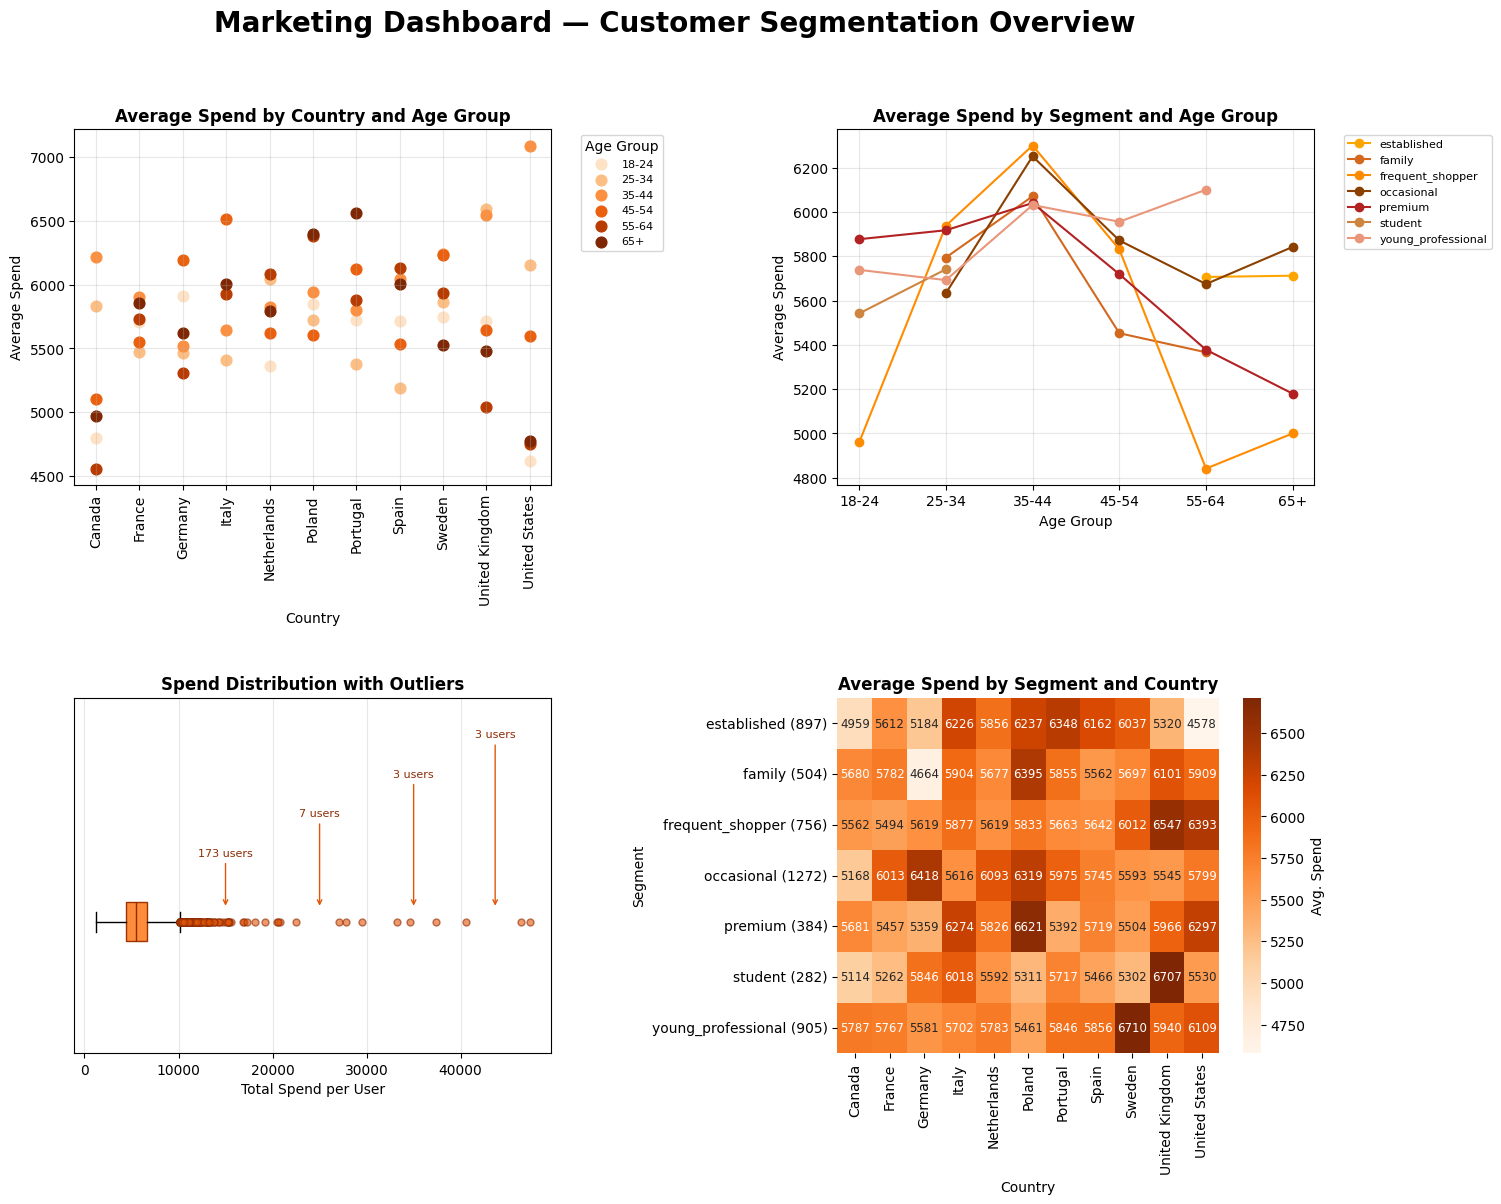

In [97]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

pivot_pais_edat = volum_per_usuari.pivot_table(index="country", columns="age_group", values="total_gastat", aggfunc="mean", observed=False)
pivot_pais_edat_llarg = pivot_pais_edat.reset_index().melt(id_vars="country", var_name="age_group", value_name="avg_spend")
cmap_edat = plt.cm.Oranges
edats_unique = pivot_pais_edat_llarg["age_group"].unique()
colors_edat = {edat: cmap_edat(0.15 + 0.85 * i / (len(edats_unique)-1)) for i, edat in enumerate(edats_unique)}
for edat in edats_unique:
    subset = pivot_pais_edat_llarg[pivot_pais_edat_llarg["age_group"] == edat]
    axes[0,0].scatter(subset["country"], subset["avg_spend"], label=edat, color=colors_edat[edat], s=60)
axes[0,0].set_xlabel("Country")
axes[0,0].set_ylabel("Average Spend")
axes[0,0].set_title("Average Spend by Country and Age Group", fontweight="bold", fontsize=12)
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title="Age Group")
plt.setp(axes[0,0].get_xticklabels(), rotation=90)
axes[0,0].grid(alpha=0.3)

colors_lines = ["#FFA500", "#D2691E", "#FF8C00", "#8B4000", "#B22222", "#CD853F", "#E9967A"]
plt.sca(axes[0,1])
for color, segment in zip(colors_lines, pivot_segment_edat.index):
    valors = pivot_segment_edat.loc[segment]
    axes[0,1].plot(valors.index, valors.values, marker="o", label=segment, color=color)
axes[0,1].set_xlabel("Age Group")
axes[0,1].set_ylabel("Average Spend")
axes[0,1].set_title("Average Spend by Segment and Age Group", fontweight="bold", fontsize=12)
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
axes[0,1].grid(alpha=0.3)

bp = axes[1,0].boxplot(volum_per_usuari["total_gastat"], vert=False, patch_artist=True, boxprops=dict(facecolor=plt.cm.Oranges(0.5), edgecolor=plt.cm.Oranges(0.9)), medianprops=dict(color=plt.cm.Oranges(0.95)),
                       flierprops=dict(marker="o", markerfacecolor=plt.cm.Oranges(0.7), markeredgecolor=plt.cm.Oranges(0.95), markersize=5, alpha=0.6))
axes[1,0].set_xlabel("Total Spend per User")
axes[1,0].set_title("Spend Distribution with Outliers", fontweight="bold", fontsize=12)
axes[1,0].set_yticks([])
axes[1,0].grid(alpha=0.3, axis="x")
axes[1,0].set_ylim(0.5, 1.85)
trams = [(10000, 20000), (20000, 30000), (30000, 40000), (40000, volum_per_usuari["total_gastat"].max() + 1)]
etiquetes_y = [1.25, 1.4, 1.55, 1.7]
for (lim_inf, lim_sup), y_pos in zip(trams, etiquetes_y):
    n_usuaris = ((volum_per_usuari["total_gastat"] > lim_inf) & (volum_per_usuari["total_gastat"] <= lim_sup)).sum()
    x_centre = (lim_inf + min(lim_sup, 48000)) / 2
    axes[1,0].annotate(f"{n_usuaris} users", xy=(x_centre, 1.05), xytext=(x_centre, y_pos), ha="center", fontsize=8, color=plt.cm.Oranges(0.95), arrowprops=dict(arrowstyle="->", color=plt.cm.Oranges(0.7), lw=1))


labels_amb_n = [f"{seg} ({int(resum_segment.loc[seg, 'num_usuaris'])})" for seg in pivot_segment_pais.index]
hm = sns.heatmap(pivot_segment_pais, annot=True, fmt=".0f", cmap="Oranges", ax=axes[1,1], cbar_kws={"label": "Avg. Spend"}, annot_kws={"size": 8.5}, yticklabels=labels_amb_n)
axes[1,1].set_title("Average Spend by Segment and Country", fontweight="bold", fontsize=12)
axes[1,1].set_xlabel("Country")
axes[1,1].set_ylabel("Segment")

plt.suptitle("Marketing Dashboard — Customer Segmentation Overview", fontsize=20, fontweight="bold")
plt.subplots_adjust(wspace=0.60, hspace=0.60)
plt.show()

Creuant país i franja d'edat, es detecten patrons molt diferents segons el mercat: a **Estats Units, la franja 35-44 anys destaca clarament per sobre de la resta** (7.093€, el valor més alt de tota l'anàlisi), mentre que als **18-24** anys es registra el valor més baix del país (4.620€). A **Polònia**, en canvi, el patró és totalment diferent: les franges de més edat (**55-64** i **65+**) són les que concentren la despesa més alta (6.380€ i 6.394€ respectivament), mentre que el mínim es dona als **45-54** anys (5.607€). Aquest contrast confirma que **no existeix una única franja d'edat universal**: cal ajustar l'edat objectiu de les campanyes segons el país concret.

Creuant segment i edat, la franja **35-44** anys destaca amb la despesa més alta en la majoria de segments (*frequent_shopper*, *occasional*, *family*, *premium*), però no de manera universal: *young_professional* té el seu propi pic als **55-64** anys (6.100€), i *established* només té representació a partir dels **55-64** anys, sense dades per a cap franja anterior. *Student*, per la seva banda, no té representació més enllà dels **25-34** anys. En conjunt, **35-44** continua sent la franja més rendible de manera transversal per a la majoria de segments, però convé no aplicar cap campanya de manera uniforme a tots ells.

La distribució de despesa mostra que la immensa majoria d'usuaris es mouen en un rang moderat (bastant per sota dels 10.000€), però hi ha un grup decreixent i clarament identificable d'usuaris d'alt valor: 173 usuaris entre 10.000€ i 20.000€, 7 entre 20.000€ i 30.000€, 3 entre 30.000€ i 40.000€, i 3 usuaris que superen els 40.000€ (amb un màxim de 47.333€). Aquest reduït grup final, tot i representar menys d'un 0,1% dels usuaris, aporta un valor molt per sobre de la mitjana i mereixeria una estratègia de fidelització exclusiva.

Finalment, el creuament de segment i país mostra que la despesa mitjana global és més alta a **Polònia**, **Regne Unit**, **Itàlia** i **Suècia** (per aquest ordre, sumant tots els segments), amb **Portugal** també ben posicionat per davant de mercats consolidats com **Estats Units** o **Alemanya**. Ara bé, de cara a decidir on expandir-se, el factor rellevant no és només qui gasta més, sinó qui ho fa sense tenir encara oferta local: només **Polònia** i **Portugal** compleixen aquesta doble condició (despesa alta i absència de companyia local), ja que **Itàlia**, **Suècia**, **Regne Unit** i **Estats Units** ja compten amb companyies pròpies. Aquesta troballa reforça, des de la perspectiva de l'usuari, la mateixa oportunitat que ja apuntava l'anàlisi de companyies: afiliar-hi oferta local a **Polònia** i **Portugal** seria una via de creixement especialment atractiva.

Creuant els tres eixos (segment, edat i país), es poden identificar combinacions molt més precises que treballar amb cada dimensió per separat. Els usuaris del segment *premium* a **Polònia**, entre **35-44** anys, combinen el país amb més despesa per a aquest segment amb una de les seves franges d'edat més fortes. Els usuaris *young_professional* de **Suècia** destaquen especialment entre els **55-64** anys, on aquest segment té el seu propi pic de despesa. I els usuaris de **Estats Units**, de **35-44** anys, representen la combinació país-edat més rendible de tota l'anàlisi (7.093€), molt per sobre de qualsevol altra combinació.

**Recomanacions per a Marketing:**
- Ajustar l'edat objectiu de les campanyes segons el país, en lloc d'aplicar una franja única: per exemple, **35-44** anys als Estats Units, però **55-64**/**65+** a **Polònia**.
- Dissenyar una campanya específica dirigida a usuaris de **35-44** anys als **Estats Units**, la combinació país-edat amb la despesa mitjana més alta de tota l'anàlisi.
- Prioritzar el segment *young_professional* amb un enfocament d'edat diferenciat (**55-64** anys) i el segment *established* amb un enfocament exclusiu a partir dels **55** anys, ja que cap dels dos segueix el patró general de **35-44**.
- Dissenyar una estratègia de fidelització exclusiva per als 3 usuaris que superen els **40.000€** de despesa, i una de nivell inferior per als usuaris entre **10.000€** i **40.000€**, atès el valor desproporcionat que aporten.
- Traslladar a l'equip comercial la prioritat d'afiliar companyies a **Polònia** i **Portugal**: combinen una demanda desatesa amb un dels perfils de despesa més alts de tot el negoci, a diferència d'altres països amb despesa igualment alta (**Itàlia**, **Suècia**, **Regne Unit**, **Estats Units**) que ja compten amb oferta local pròpia.

## Exercici 2: Informe executiu

**🎯 Objectiu:** A partir del dashboard, presenta un informe executiu en dues versions:

- Sense IA
- Amb suport d'IA

<br>
» Sense IA:

Redactada amb les teves pròpies paraules.

» Amb suport d'IA:

Utilitzant eines d'IA per:

  - Millorar la redacció.
  - Adaptar el llenguatge al departament escollit.
  - Incorporar vocabulari tècnic de negoci.

L'informe ha de contenir obligatòriament:

1. Resum general (màx. 5 línies): Què s'ha analitzat i amb quin objectiu.

2. Troballes clau (3-5): Insights sòlids basats en dades reals.

3. Riscos detectats: Per exemple: dependència excessiva de productes o empreses, manca de captació de nous usuaris, franges horàries crítiques, possibles indicis de frau o anomalies...

4. Oportunitats: millores operatives, segments no explotats, productes o franges amb potencial, optimització de recursos...

5. Recomanacions: Accions concretes i no tècniques, orientades a negoci.

<br>

```
📌 Clau del nivell 3

No es tracta de demostrar que saps fer gràfics, sinó de demostrar que entens les dades i saps explicar què s'ha de fer amb elles.

Implementar estratègies comercials orientades a la fidelització i a la previsibilitat del volum de vendes.
```

### **Informe Executiu sense suport de IA**


#### **Resum general**
S'ha analitzat la despesa mitjana per país i rang d'edat, quina despesa mitjana hi ha segons el rang d'edat i segment, quins països gasten més per segment i com es reparteix la despesa total entre els usuaris.  
L'objectiu és entendre qui compra més, on es compra més i quins perfils aporten més ingressos, per poder prendre decisions de negoci més encertades, ja sigui per apostar per certes campanyes o deixar d'invertir en altres.

---

#### **Troballes clau**
- **El segment “occasional” és el més gran**: té **1.272 usuaris**, molt per sobre de la resta. *young_professional* i *established* també tenen molts usuaris, mentre que *student* és el segment més petit (no arriba als **300** usuaris).  
- **Les persones de 35 a 44 anys són les que més gasten**: en tots els segments, aquesta franja d'edat supera els **6.000€** de despesa mitjana, destacant Estats Units, amb una despesa mitjana de més de **7.000€**.
- **La majoria d'usuaris gasten entre 4.000€ i 6.000€**: el punt més habitual és al voltant dels **5.500€**, cosa que indica que la despesa és estable i moderada.  
- **Hi ha països que destaquen clarament**: Suècia (**6.710€** en *young_professional*), Regne Unit (**6.707€** *en student* i **6547€** en *frequent_shopper*) i Polònia (**6.621€** en *premium*) tenen les despeses mitjanes més altes.  
- **Hi ha segments que funcionen malament en alguns països**: *family* a Alemanya (**4.664€**) i *established* a United States (**4.578€**) estan molt per sota de la mitjana global.  
- **Hi ha un gran pic que abarca dels 25 als 54 anys**: En aquest pic, pràcticament tots els segments estàn per sobre dels **5.600€** de despesa mitjana.
- **Hi ha 13 usuaris amb despeses molt altes**: entre **20.000€ i 47.000€**. Són casos excepcionals que poden ser clients VVIP. Però també hi ha un gran grup de **173 usuaris** amb compres entre **10.000€** i **20.000€**.

---

#### **Riscos detectats**
- **Depenem massa de la franja d'edat 35-44**: si aquest grup compra menys, els ingressos baixaran de manera directa.  
- **Alemanya i Estats Units tenen segments febles**: la despesa mitjana dels segments *family* (Alemanya) i *established* (Estats Units) és de llarg la més baixa.
- **La despesa està massa concentrada en imports moderats**: això limita el creixement en productes premium si no es capten més clients de despesa alta.  
- **Els 13 usuaris amb despesa molt alta poden distorsionar les mitjanes**: cal revisar si són clients especials, puntuals o errors de facturació o introducció de dades.

---

#### **Oportunitats**
- **Països amb potencial alt**: Suècia, Regne Unit i Polònia tenen despeses mitjanes molt altes; són bons candidats per impulsar programes de fidelització.  
- **Països amb marge de millora**: Alemanya i Estats Units necessiten una estratègia específica per potenciar segments que hi funcionen malament.  
- **La franja 35-44 és clau**: és el grup que més gasta; cal centrar-hi campanyes i ofertes.  
- **El segment occasional és el més nombros amb diferéncia**: cal centrar campanyes per convertir-los a *frequent_shopper*.
- **Segments joves amb potencial**: *student* i *young_professional* poden créixer si se'ls ofereixen programes de punts, subscripcions o descomptes recurrents.  
- **Gestió dels clients de despesa molt alta**: poden ser perfils VVIP que val la pena fidelitzar amb ofertes personalitzades.
- **Gestió dels usuaris que realitzen compres entre el 10.000 i 20.000€:** entrarien com a perfils VIP, el seu moviment (en conjunt) de diners és molt més elevat que els VVIP.

---
>
>### **Recomanacions**
><br>
>
>**Impulsar campanyes en països d'alt valor (Suècia, Regne Unit, Polònia)**  
>- Promocionar productes d'acord en els segments on destaquen respectivament(*young_professional*, *student* i *premium*).     
><br>
>
>**Millorar resultats en països febles (Alemanya i Estats Units)**  
>- Analitzar què falla: competència, preus, preferències locals.
>- Adaptar preus i productes per al segment *family* a Alemanya.  
>- Reposicionar el segment *established* als Estats Units amb garanties, packs o programes de fidelització.  
><br>
>
>**Fer créixer els segments joves**  
>- Crear programes de punts, subscripcions o descomptes per compres repetides.  
>- Utilitzar canals digitals (TikTok, Instagram, etc) per captar *student* i *young_professional*.  
>- Oferir productes d'entrada més econòmics.
><br>
>
>**Prioritzar la franja d'edat 35-44**  
>- Fer campanyes específiques per aquest grup, especialment per Estats Units i Regne Unit.
>- Enfocar missatges en durabilitat, qualitat i valor.  
>- Aprofitar per crear ofertes per ampliar rendibilitat en el pic dels 25 als 54 anys.
><br>
>
>**El segment d'usuaris occasional és el més nombrós**
>- Potenciar els productes més venuts en aquest segment.
>- Fer campanyes per convertir usuaris ocasionals en freqüents.
><br>
>
>**Gestionar els usuaris de despesa molt alta VVIP**  
>- Revisar si són VVIP o casos puntuals.  
>- En els casos que siguin clients VVIP, crear un seguiment especial per aquests perfils/usuaris amb ofertes personalitzades.
><br>
>
>**Fidelitzar els usuaris VIP**:
>- Campanyes enfocades per fidelitzar aquests clients.




---

### **Informe Executiu — Amb suport d'IA**

#### **Resum general**

Aquest informe analitza el comportament de despesa de la base de clients (usuaris) creuant tres dimensions: segment, franja d'edat i país. L'objectiu és identificar quins perfils de client concentren més valor, detectar segments o mercats amb baix rendiment, i traduir aquests patrons en recomanacions accionables per a Marketing, orientades a la fidelització i a fer més previsible el volum de vendes.

---

#### **Troballes clau**

- **El pes del negoci no és homogeni entre segments**: *occasional* concentra 1.272 usuaris, molt per sobre de *young_professional* i *established* (al voltant de 900 cadascun), mentre que *student* (282 usuaris) és clarament minoritari. La diferència de volum, no la despesa individual, és el que distingeix els segments.
- **35-44 anys és la franja de despesa transversalment més alta**, superant els 6.000€ de mitjana en la majoria de segments, amb un màxim destacat als Estats Units (7.093€) — la combinació país-edat més rendible de tot l'anàlisi.
- **El comportament per edat no és universal per país**: mentre als Estats Units el pic es concentra clarament als 35-44 anys, a Polònia les franges de més edat (55-64 i 65+) superen els 6.300€, amb el mínim als 45-54 anys. Aplicar una única franja d'edat a totes les campanyes seria ineficient.
- **Polònia, Regne Unit, Itàlia i Suècia lideren la despesa mitjana agregada per país**, amb Portugal també ben posicionat per davant de mercats consolidats com els Estats Units o Alemanya.
- **La cua de despesa alta és reduïda però significativa**: 173 usuaris entre 10.000€ i 20.000€, i 13 usuaris addicionals que superen els 20.000€ (fins a un màxim de 47.333€). Junts, representen un grup reduït però d'alt valor per càpita.

---

#### **Riscos detectats**

- **Concentració excessiva en una única franja d'edat (35-44 anys)**: una campanya centrada exclusivament en aquest perfil deixa la previsibilitat de vendes exposada a qualsevol canvi en el comportament d'aquest grup concret.
- **Rendiment feble en combinacions específiques segment-país**: *family* a Alemanya (4.664€) i *established* als Estats Units (4.578€) se situen molt per sota de la mitjana global, indicant una possible desconnexió entre l'oferta i la demanda local en aquests casos.
- **Manca de segmentació fina en l'estratègia d'edat**: aplicar el mateix missatge de 35-44 anys a tots els països (per exemple, a Polònia, on aquesta franja no és la més rendible) comportaria una pèrdua d'eficiència en la inversió de màrqueting.
- **Presència d'usuaris d'alt valor no gestionats de manera diferenciada**: els 13 usuaris per sobre de 20.000€ (i especialment els 3 que superen els 40.000€) requereixen validació —per descartar errors de facturació— i, si es confirmen com a clients legítims, un tractament de fidelització a mida que actualment no existeix.

---

#### **Oportunitats**

- **Mercats d'alt valor per reforçar fidelització**: Suècia (*young_professional*, 6.710€), Regne Unit (*student*, 6.707€; *frequent_shopper*, 6.547€) i Polònia (*premium*, 6.621€) ofereixen el millor retorn esperat per campanyes de retenció segmentades.
- **Mercats amb marge de millora clar**: Alemanya (*family*) i Estats Units (*established*) representen una oportunitat de recuperació si es diagnostica la causa del baix rendiment (preu, posicionament, competència local).
- **Personalització de l'edat objectiu per país**: aprofitar el patró país-edat (35-44 als EUA, 55-64/65+ a Polònia) per dissenyar creatiu i missatge diferenciats, en lloc d'una campanya única.
- **Conversió del segment *occasional***: com a segment més nombrós, un programa de fidelització orientat a augmentar-ne la freqüència de compra (convertir-los en *frequent_shopper*) té el màxim potencial d'impacte agregat.
- **Desenvolupament de segments joves (*student*, *young_professional*)**: programes d'entrada (punts, subscripcions, descomptes recurrents) per capturar-los abans que migrin a segments de major valor per compte propi.
- **Programa de client d'alt valor (VIP/VVIP) en dos nivells**: els 173 usuaris entre 10.000€-20.000€ (volum agregat elevat) i els 13 usuaris per sobre de 20.000€ (valor individual excepcional) justifiquen tractaments diferenciats però tots dos rendibles de fidelitzar.

---

>### **Recomanacions**
>
>**1. Impulsar campanyes segmentades als mercats d'alt valor**
>- Suècia → *young_professional*; Regne Unit → *student* i *frequent_shopper*; >Polònia → *premium*.
>- Ajustar el missatge creatiu al perfil dominant de cada mercat, no a una >plantilla única.
>
>**2. Diagnosticar i corregir el rendiment feble a Alemanya i Estats Units**
>- Analitzar preu, posicionament competitiu i preferències locals per a >*family* (Alemanya) i *established* (Estats Units).
>- Pilotar ajustos de catàleg o packs específics abans d'escalar la inversió.
>
>**3. Personalitzar l'edat objectiu segons el país**
>- Estats Units i Regne Unit → prioritzar 35-44 anys, amb missatges de qualitat >i valor a llarg termini.
>- Polònia → prioritzar 55-64/65+, amb un enfocament diferent al de la resta de >mercats.
>
>**4. Activar la conversió del segment *occasional* a *frequent_shopper***
>- Identificar els productes més venuts dins d'aquest segment com a palanca >d'entrada.
>- Dissenyar una campanya de conversió amb incentius a la recompra.
>
>**5. Desenvolupar programes d'entrada per a segments joves**
>- *Student* i *young_professional*: subscripcions, punts o descomptes >recurrents.
>- Prioritzar canals digitals (xarxes socials) coherents amb aquest perfil >demogràfic.
>
>**6. Establir un programa de client d'alt valor en dos nivells**
>- Nivell VIP (173 usuaris, 10.000€-20.000€): fidelització estàndard amb >beneficis escalables.
>- Nivell VVIP (13 usuaris, >20.000€): validar autenticitat de les dades i, un >cop confirmats, oferir gestió personalitzada i comunicació directa.

